# Phase 4 — Baseline Model

## Objective

The objective of Phase 4 is to establish a reliable baseline machine learning model for predicting payment difficulties using the `application_train` dataset as the primary modeling dataset.

The baseline phase focuses on understanding the modeling dataset, performing exploratory data analysis, identifying data-quality issues, cleaning and preprocessing the data, handling missing values, building a baseline model, and evaluating its performance.

The baseline model will provide a benchmark against which the feature-engineered models developed in later phases can be compared.

### Phase 4 Workflow

1. Load and inspect the `application_train` dataset
2. Perform initial data quality assessment
3. Analyze the target variable
4. Identify missing values
5. Perform exploratory data analysis
6. Identify invalid values and potential outliers
7. Clean and preprocess the data
8. Handle missing values
9. Build a baseline machine learning model
10. Evaluate model performance
11. Document baseline findings and limitations

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
application_df=pd.read_csv(r'C:\Users\HomePC\Desktop\home_credit_dataset\application_train.csv')

In [4]:
application_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
application_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
application_df.shape

(307511, 122)

In [7]:
application_df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

## 1. Dataset Overview

The `application_train` dataset is used as the primary modeling dataset for the baseline model.

The dataset contains **307,511 observations and 122 columns**. It includes applicant-level information such as demographic characteristics, financial information, employment details, credit-related variables, and the target variable `TARGET`.

The dataset contains:

- **307,511 rows**
- **122 columns**
- **65 float columns**
- **41 integer columns**
- **16 categorical/object columns**

The dataset is therefore a high-dimensional tabular dataset containing both numerical and categorical features.

At this stage, the raw dataset has been loaded without applying any cleaning or transformation so that the underlying data-quality issues can be assessed before treatment.

In [8]:
df_target=pd.DataFrame({'target':application_df['TARGET'].value_counts(),
                        'target_percentage':(application_df['TARGET'].value_counts(normalize=True)*100).values})
df_target

                    

,target,target_percentage
TARGET,,
0,282686,91.927118
1,24825,8.072882


## 2. Target Variable Analysis

The target variable `TARGET` represents whether an applicant experienced payment difficulties.

- `TARGET = 0` → Applicant did not experience payment difficulties
- `TARGET = 1` → Applicant experienced payment difficulties

The target distribution is highly imbalanced.

Approximately **91.93% of applicants belong to class 0**, while only **8.07% belong to class 1**.

This class imbalance is an important consideration for the baseline modeling process. Accuracy alone would not be an appropriate primary evaluation metric because a model could achieve high accuracy simply by predicting the majority class for most applicants.

Therefore, model evaluation will focus particularly on **precision, recall, F1-score, ROC-AUC, and PR-AUC**, with special attention to recall for the risky class (`TARGET = 1`).

In [9]:
df_missing=pd.DataFrame({'missing':application_df.isnull().sum(),
                        'missing_pct':(application_df.isnull().sum()/application_df.shape[0]*100).values.round(2)})
df_missing=df_missing[df_missing['missing']>0].sort_values(by='missing',ascending=False)
df_missing

                    

,missing,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
...,...,...
EXT_SOURCE_2,660,0.21
AMT_GOODS_PRICE,278,0.09
AMT_ANNUITY,12,0.00
CNT_FAM_MEMBERS,2,0.00


## 3. Missing Value Assessment

A missing-value assessment was performed across all 122 columns to understand the extent of incomplete information in the dataset.

The analysis identified **67 columns containing missing values**.

Several features have a substantial proportion of missing observations. For example:

- `COMMONAREA_MEDI` → 69.87% missing
- `COMMONAREA_AVG` → 69.87% missing
- `COMMONAREA_MODE` → 69.87% missing
- `NONLIVINGAPARTMENTS_MEDI` → 69.43% missing
- `NONLIVINGAPARTMENTS_MODE` → 69.43% missing

The percentage of missing values varies considerably across features, ranging from very small amounts of missing data to more than 69%.

At this stage, no missing values have been imputed or removed.

The purpose of this initial assessment is to understand the missingness pattern before deciding on an appropriate treatment strategy. Missing values will be addressed after completing the initial exploratory analysis.

In [10]:
application_df.duplicated().sum()

np.int64(0)

In [11]:
application_df['SK_ID_CURR'].duplicated().sum()

np.int64(0)

## 4. Duplicate Record Assessment

The dataset was checked for duplicate records to ensure that duplicate observations do not affect the baseline model.

Two types of duplication were considered:

1. Completely duplicated rows across all columns.
2. Duplicate applicant identifiers using `SK_ID_CURR`.

No completely duplicated records were identified in the dataset.

Additionally, `SK_ID_CURR` was checked to ensure that each applicant is represented only once in the `application_train` dataset.

Based on these checks, no duplicate-record treatment is required at this stage.

In [12]:
num_cols=application_df.select_dtypes(include=['int64','float64']).columns
len(num_cols)

106

In [13]:
application_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


### Numerical Feature Summary

Descriptive statistics were generated for the 106 numerical columns to understand their distributions, ranges, and potential data-quality issues.

Several observations were identified during the initial numerical analysis:

- `SK_ID_CURR` is an applicant identifier and does not represent a meaningful predictive feature. It will be excluded from model training.
- `TARGET` is a binary variable with a mean of approximately 0.081, confirming the class imbalance identified earlier.
- `CNT_CHILDREN` has a median of 0 and a maximum value of 19, which requires further investigation before determining whether extreme values represent valid observations or data-quality issues.
- `AMT_INCOME_TOTAL` shows substantial right skew, with a median of 147,150 and a maximum of 117,000,000. This indicates the presence of potentially extreme income values that require further investigation.
- Several credit-bureau request variables are heavily concentrated around zero and contain relatively large maximum values, suggesting skewed distributions and potential extreme observations.

These observations do not automatically indicate erroneous data. Further investigation using distributions, frequency analysis, and domain context will be performed before deciding whether any values require treatment.

In [14]:
skewness = application_df[num_cols].skew().sort_values(ascending=False)

skewness.head(15)

FLAG_DOCUMENT_12             392.114779
AMT_INCOME_TOTAL             391.559654
FLAG_DOCUMENT_10             209.589054
FLAG_DOCUMENT_2              153.791817
AMT_REQ_CREDIT_BUREAU_QRT    134.365776
FLAG_DOCUMENT_4              110.894364
FLAG_DOCUMENT_7               72.174108
FLAG_DOCUMENT_17              61.214140
FLAG_DOCUMENT_21              54.612939
FLAG_DOCUMENT_20              44.364897
FLAG_DOCUMENT_19              40.956134
FLAG_DOCUMENT_15              28.699333
AMT_REQ_CREDIT_BUREAU_DAY     27.043505
FLAG_DOCUMENT_14              18.372533
FLAG_DOCUMENT_13              16.753746
dtype: float64

In [15]:
skewness.tail(15)

DAYS_BIRTH                       -0.115673
EXT_SOURCE_3                     -0.409390
DAYS_REGISTRATION                -0.590872
DAYS_LAST_PHONE_CHANGE           -0.713606
EXT_SOURCE_2                     -0.793576
FLAG_DOCUMENT_3                  -0.925725
YEARS_BUILD_AVG                  -0.962485
YEARS_BUILD_MEDI                 -0.962784
YEARS_BUILD_MODE                 -1.002305
FLAG_EMP_PHONE                   -1.664886
YEARS_BEGINEXPLUATATION_MODE    -14.755318
YEARS_BEGINEXPLUATATION_AVG     -15.515264
YEARS_BEGINEXPLUATATION_MEDI    -15.573124
FLAG_CONT_MOBILE                -23.081172
FLAG_MOBIL                     -554.536744
dtype: float64

### Skewness Analysis

Skewness was calculated for the numerical features to identify variables with highly asymmetric distributions.

Several features showed very high positive or negative skewness. However, high skewness does not necessarily indicate a data-quality problem.

Many of the highly skewed features are binary indicator variables such as `FLAG_DOCUMENT_*`, `FLAG_MOBIL`, and `FLAG_CONT_MOBILE`. These variables are expected to be highly imbalanced because most applicants have the same indicator value. Therefore, their high skewness should not be interpreted as evidence of outliers.

Among the continuous and count-based variables, `AMT_INCOME_TOTAL` and `AMT_REQ_CREDIT_BUREAU_QRT` show substantial positive skewness and require further investigation.

The skewness analysis will therefore be used as a screening step rather than as an automatic criterion for outlier removal or feature elimination.

In [16]:
application_df.columns=application_df.columns.str.lower()

In [17]:
application_df.columns

Index(['sk_id_curr', 'target', 'name_contract_type', 'code_gender',
       'flag_own_car', 'flag_own_realty', 'cnt_children', 'amt_income_total',
       'amt_credit', 'amt_annuity',
       ...
       'flag_document_18', 'flag_document_19', 'flag_document_20',
       'flag_document_21', 'amt_req_credit_bureau_hour',
       'amt_req_credit_bureau_day', 'amt_req_credit_bureau_week',
       'amt_req_credit_bureau_mon', 'amt_req_credit_bureau_qrt',
       'amt_req_credit_bureau_year'],
      dtype='object', length=122)

In [18]:
numerical_columns=application_df.select_dtypes(include=['float64','int64']).columns.tolist()
numerical_columns.remove('sk_id_curr')
numerical_columns.remove('target')
print('number of numerical columns is :',len(numerical_columns))

number of numerical columns is : 104


In [19]:
cont_variables=[col for col in numerical_columns if application_df[col].nunique(dropna=True)>2]
print('number of continuous columns is :',len(cont_variables))

number of continuous columns is : 72


In [20]:
continuous_skewness = (
    application_df[cont_variables]
    .skew()
    .sort_values(ascending=False)
)

continuous_skewness.head(15)

amt_income_total              391.559654
amt_req_credit_bureau_qrt     134.365776
amt_req_credit_bureau_day      27.043505
nonlivingapartments_mode       16.251819
nonlivingapartments_medi       15.671995
nonlivingapartments_avg        15.541185
amt_req_credit_bureau_hour     14.534062
obs_30_cnt_social_circle       12.139598
obs_60_cnt_social_circle       12.070829
amt_req_credit_bureau_week      9.293573
amt_req_credit_bureau_mon       7.804848
nonlivingarea_avg               6.559012
nonlivingarea_mode              6.522451
nonlivingarea_medi              6.508831
commonarea_mode                 5.620589
dtype: float64

In [21]:
continuous_skewness.tail(15)

region_rating_client             0.087468
region_rating_client_w_city      0.059730
hour_appr_process_start         -0.028024
ext_source_1                    -0.068755
days_birth                      -0.115673
ext_source_3                    -0.409390
days_registration               -0.590872
days_last_phone_change          -0.713606
ext_source_2                    -0.793576
years_build_avg                 -0.962485
years_build_medi                -0.962784
years_build_mode                -1.002305
years_beginexpluatation_mode   -14.755318
years_beginexpluatation_avg    -15.515264
years_beginexpluatation_medi   -15.573124
dtype: float64

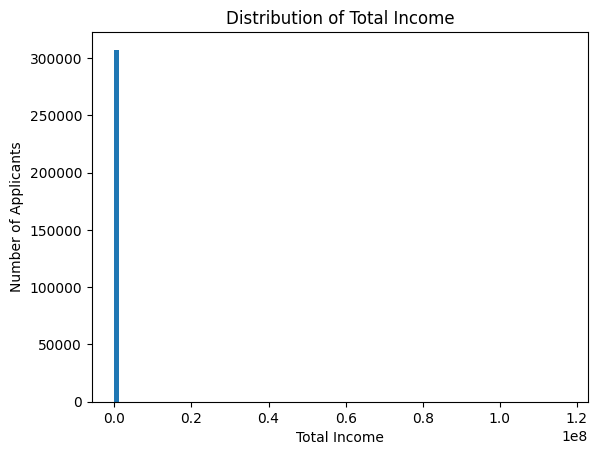

In [22]:
plt.hist(
    application_df['amt_income_total'].dropna(),
    bins=100
)

plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Number of Applicants')

plt.show()

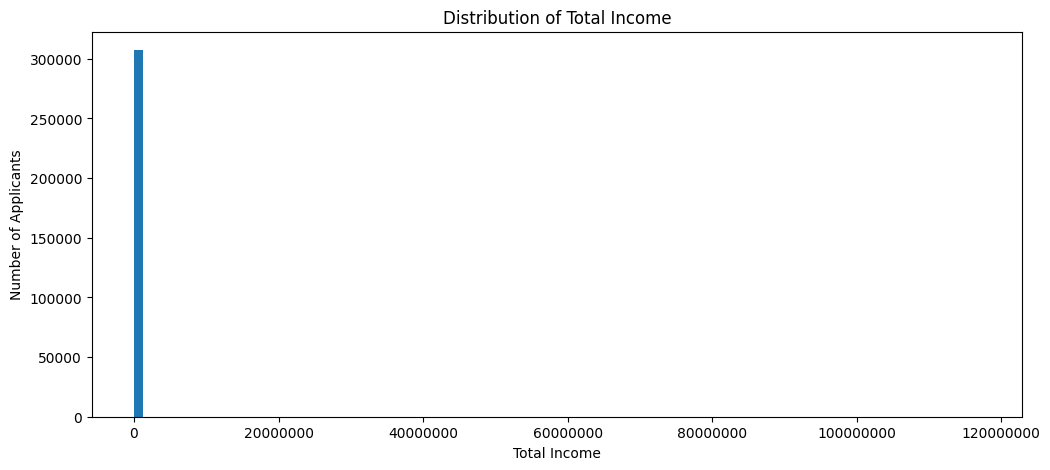

In [23]:
import matplotlib.ticker as ticker
plt.figure(figsize=(12, 5))

plt.hist(
    application_df['amt_income_total'].dropna(),
    bins=100
)

plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Number of Applicants')

plt.ticklabel_format(style='plain', axis='x')

plt.show()

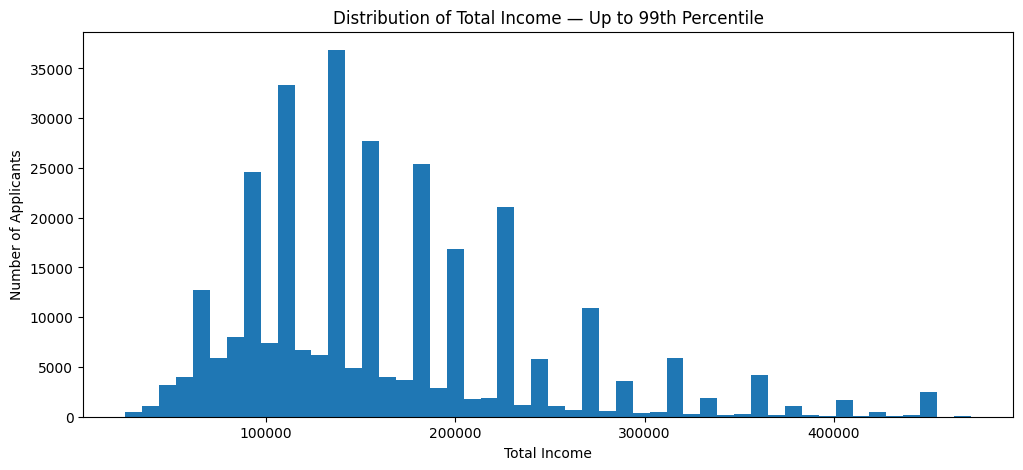

In [24]:
income_99 = application_df['amt_income_total'].quantile(0.99)

plt.figure(figsize=(12, 5))

plt.hist(
    application_df.loc[
        application_df['amt_income_total'] <= income_99,
        'amt_income_total'
    ].dropna(),
    bins=50
)

plt.title('Distribution of Total Income — Up to 99th Percentile')
plt.xlabel('Total Income')
plt.ylabel('Number of Applicants')

plt.ticklabel_format(style='plain', axis='x')

plt.show()

In [25]:
application_df['amt_income_total'].quantile([0.90,0.95,0.99,0.995,0.999])

0.900    270000.0
0.950    337500.0
0.990    472500.0
0.995    630000.0
0.999    900000.0
Name: amt_income_total, dtype: float64

## Numerical Variable EDA

### 1. `amt_income_total` — Applicant Income Distribution

The `amt_income_total` variable was examined to understand the income distribution of applicants.

Initial skewness analysis showed that `amt_income_total` has an extremely right-skewed distribution:

- Skewness: **391.56**
- Median income: **₹147,150**
- Maximum income: **₹117,000,000**

The histogram showed that most applicants are concentrated in the lower income range, while a small number of observations extend far into the upper tail.

#### Income Percentile Analysis

The following percentiles were calculated:

| Percentile | Income |
|------------|-------:|
| 90th | ₹270,000 |
| 95th | ₹337,500 |
| 99th | ₹472,500 |
| 99.5th | ₹630,000 |
| 99.9th | ₹900,000 |

#### Observations

- 90% of applicants have an income of **₹270,000 or less**.
- 95% of applicants have an income of **₹337,500 or less**.
- 99% of applicants have an income of **₹472,500 or less**.
- Only 0.5% of applicants have an income above **₹630,000**.
- Only 0.1% of applicants have an income above **₹900,000**.
- The maximum value of **₹117,000,000** is substantially higher than the 99.9th percentile, indicating a very long upper tail.

#### EDA Interpretation

`amt_income_total` is highly right-skewed, with the majority of applicants concentrated at relatively low-to-moderate income levels and a very small number of observations having exceptionally high income values.

The extreme values have not been removed or modified at this stage. Since EDA is being performed before data cleaning, these observations will be investigated further to determine whether they represent legitimate high-income applicants or potential data-quality issues.

The variable will therefore be revisited during the **Data Cleaning and Missing Value Handling** stage before finalizing the modeling dataset.

In [26]:
income_bins=[0,100000,150000,200000,250000,300000,400000,
             500000,float('inf')]
income_labels = [
    '<100K',
    '100K-150K',
    '150K-200K',
    '200K-250K',
    '250K-300K',
    '300K-400K',
    '400K-500K',
    '500K+'
]
application_df['income_bands']=pd.cut(application_df['amt_income_total'],
                                      bins=income_bins,
                                      labels=income_labels,
                                      include_lowest=True)
                                      

In [27]:
application_df.head()

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year,income_bands
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,200K-250K
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,250K-300K
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,<100K
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,100K-150K
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,100K-150K


In [28]:
application_df['income_bands'].unique()

['200K-250K', '250K-300K', '<100K', '100K-150K', '150K-200K', '300K-400K', '400K-500K', '500K+']
Categories (8, object): ['<100K' < '100K-150K' < '150K-200K' < '200K-250K' < '250K-300K' < '300K-400K' < '400K-500K' < '500K+']

In [29]:
income_default_rate = (
    application_df
    .groupby('income_bands', observed=True)['target']
    .agg(['count', 'mean'])
)

income_default_rate['default_rate_%'] = (
    income_default_rate['mean'] * 100
)

income_default_rate

,count,mean,default_rate_%
income_bands,,,
<100K,63698,0.082028,8.202769
100K-150K,91591,0.086188,8.618751
150K-200K,64307,0.084470,8.446981
200K-250K,48137,0.077446,7.744562
250K-300K,17039,0.070016,7.001585
300K-400K,14676,0.060303,6.030253
400K-500K,5361,0.060063,6.006342
500K+,2702,0.054034,5.403405


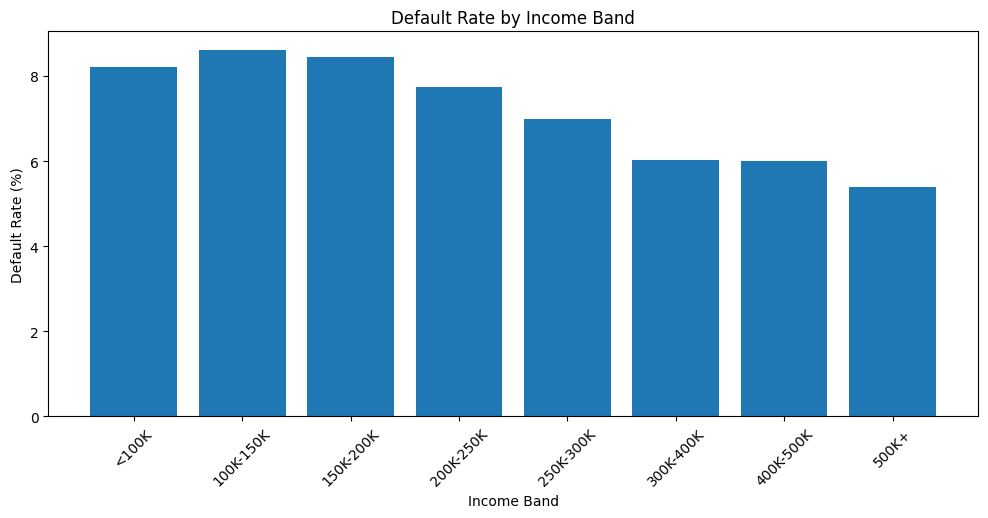

In [30]:
plt.figure(figsize=(12, 5))

plt.bar(
    income_default_rate.index.astype(str),
    income_default_rate['default_rate_%']
)

plt.title('Default Rate by Income Band')
plt.xlabel('Income Band')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=45)
plt.show()

### Income vs Default Rate

To investigate whether applicant income is associated with repayment difficulty, applicants were grouped into income bands and the default rate was calculated for each group.

The analysis shows a generally **negative relationship between income and default rate**:

- Lower-income applicants have relatively higher default rates.
- Default rates generally decrease as applicant income increases.
- This indicates that `AMT_INCOME_TOTAL` may contain useful predictive information for credit-risk modeling.
- The observed relationship should be interpreted as an association rather than causation.
- Higher-income bands contain fewer observations, so their default rates should be interpreted with greater caution.

**EDA Finding:**  
> Applicants with lower income levels tend to have higher default rates, while default rates generally decrease with increasing income.

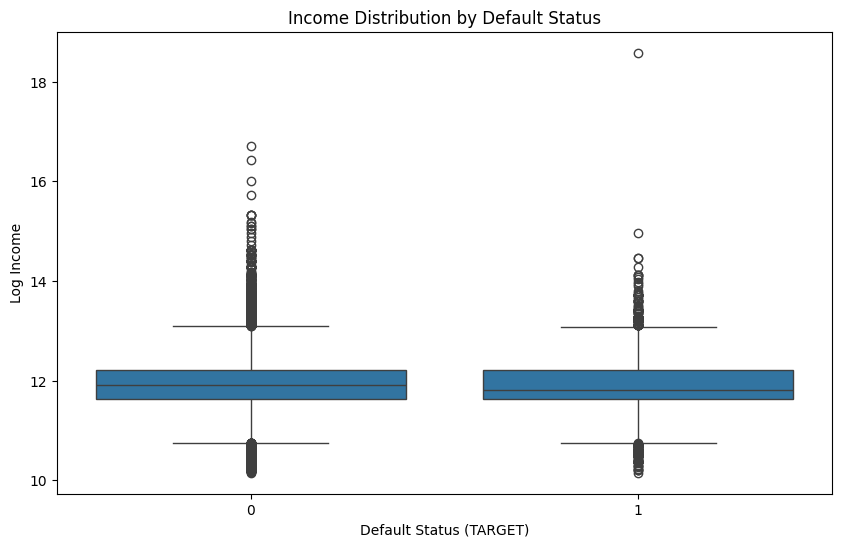

In [31]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=application_df,
    x='target',
    y=np.log1p(application_df['amt_income_total'])
)

plt.xlabel('Default Status (TARGET)')
plt.ylabel('Log Income')
plt.title('Income Distribution by Default Status')

plt.show()

### Income Distribution — Key Finding

> **`AMT_INCOME_TOTAL` shows substantial overlap between defaulters (`TARGET = 1`) and non-defaulters (`TARGET = 0`). This indicates that income alone does not provide strong separation between the two groups. Although income may still contribute to the model when combined with other features, it is unlikely to be a strong standalone predictor of default risk.**

In [32]:
application_df.dtypes.value_counts()

float64     65
int64       41
object      16
category     1
Name: count, dtype: int64

In [33]:
application_df.select_dtypes(include='number').shape

(307511, 106)

In [34]:
application_df.select_dtypes(include='object').shape

(307511, 16)

In [35]:
binary_features = [
    col for col in application_df.columns
    if application_df[col].nunique(dropna=True) == 2
]
print(len(binary_features))

37


In [36]:
cardinality = application_df.drop(columns='target').nunique(dropna=True)

cardinality.sort_values().head(20)

reg_city_not_work_city         2
flag_cont_mobile               2
flag_phone                     2
flag_email                     2
flag_document_6                2
flag_document_7                2
flag_document_8                2
reg_region_not_live_region     2
reg_region_not_work_region     2
live_region_not_work_region    2
reg_city_not_live_city         2
flag_document_9                2
live_city_not_work_city        2
flag_document_10               2
flag_document_18               2
flag_document_17               2
flag_document_16               2
flag_document_15               2
flag_document_14               2
flag_document_13               2
dtype: int64

In [37]:
cardinality.sort_values(ascending=False).head(20)

sk_id_curr                307511
ext_source_2              119831
ext_source_1              114584
days_birth                 17460
days_registration          15688
amt_annuity                13672
days_employed              12574
days_id_publish             6168
amt_credit                  5603
livingarea_mode             5301
livingarea_medi             5281
livingarea_avg              5199
totalarea_mode              5116
basementarea_mode           3841
basementarea_avg            3780
days_last_phone_change      3773
basementarea_medi           3772
landarea_mode               3563
landarea_medi               3560
landarea_avg                3527
dtype: int64

In [38]:
[col for col in application_df.columns if 'id' in col.lower()]

['sk_id_curr', 'days_id_publish']

In [39]:
num_cols

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=106)

In [40]:
num_cols=application_df.select_dtypes(include=['int64','float64']).columns
numeric_profile = pd.DataFrame({
    'dtype': application_df[num_cols].dtypes,
    'unique': application_df[num_cols].nunique(),
    'missing': application_df[num_cols].isnull().sum(),
    'missing_pct': (
        application_df[num_cols].isnull().mean() * 100
    ).round(2),
    'mean': application_df[num_cols].mean(),
    'median': application_df[num_cols].median(),
    'std': application_df[num_cols].std(),
    'min': application_df[num_cols].min(),
    'max': application_df[num_cols].max(),
    'skewness': application_df[num_cols].skew().round(2),
    'zero_pct': (
        (application_df[num_cols] == 0).mean() * 100
    ).round(2)
})

numeric_profile

,dtype,unique,missing,missing_pct,mean,median,std,min,max,skewness,zero_pct
sk_id_curr,int64,307511,0,0.0,278180.518577,278202.0,102790.175348,100002.0,456255.0,-0.00,0.00
target,int64,2,0,0.0,0.080729,0.0,0.272419,0.0,1.0,3.08,91.93
cnt_children,int64,15,0,0.0,0.417052,0.0,0.722121,0.0,19.0,1.97,70.04
amt_income_total,float64,2548,0,0.0,168797.919297,147150.0,237123.146279,25650.0,117000000.0,391.56,0.00
amt_credit,float64,5603,0,0.0,599025.999706,513531.0,402490.776996,45000.0,4050000.0,1.23,0.00
...,...,...,...,...,...,...,...,...,...,...,...
amt_req_credit_bureau_day,float64,9,41519,13.5,0.007000,0.0,0.110757,0.0,9.0,27.04,86.01
amt_req_credit_bureau_week,float64,9,41519,13.5,0.034362,0.0,0.204685,0.0,8.0,9.29,83.72
amt_req_credit_bureau_mon,float64,24,41519,13.5,0.267395,0.0,0.916002,0.0,27.0,7.80,72.27
amt_req_credit_bureau_qrt,float64,11,41519,13.5,0.265474,0.0,0.794056,0.0,261.0,134.37,70.05


In [41]:
numeric_profile['high_missing']=numeric_profile['missing_pct']>30
numeric_profile['high_skew']=numeric_profile['skewness'].abs()>2
numeric_profile['low_unique']=numeric_profile['unique']<=10
numeric_profile['high_zeropct']=numeric_profile['zero_pct']>50

In [42]:
numeric_profile[['high_missing','high_skew','low_unique','high_zeropct']].sum()

high_missing    45
high_skew       72
low_unique      40
high_zeropct    39
dtype: int64

In [43]:
numeric_profile['profile_flags'] = (
    numeric_profile[['high_missing',
                     'high_skew',
                     'low_unique',
                     'high_zeropct']]
    .sum(axis=1)
)

numeric_profile.sort_values(
    by='profile_flags',
    ascending=False
)[[
    'profile_flags',
    'missing_pct',
    'skewness',
    'zero_pct',
    'unique'
]].head(30)

,profile_flags,missing_pct,skewness,zero_pct,unique
flag_document_12,3,0.00,392.11,100.00,2
flag_document_2,3,0.00,153.79,100.00,2
target,3,0.00,3.08,91.93,2
flag_document_13,3,0.00,16.75,99.65,2
flag_document_15,3,0.00,28.70,99.88,2
flag_document_16,3,0.00,9.89,99.01,2
def_30_cnt_social_circle,3,0.33,5.18,88.23,10
reg_city_not_live_city,3,0.00,3.14,92.18,2
reg_region_not_work_region,3,0.00,4.09,94.92,2
reg_region_not_live_region,3,0.00,7.94,98.49,2


In [44]:
binary_cols = [
    col for col in num_cols
    if application_df[col].nunique(dropna=True) == 2
]

len(binary_cols), binary_cols

(33,
 ['target',
  'flag_mobil',
  'flag_emp_phone',
  'flag_work_phone',
  'flag_cont_mobile',
  'flag_phone',
  'flag_email',
  'reg_region_not_live_region',
  'reg_region_not_work_region',
  'live_region_not_work_region',
  'reg_city_not_live_city',
  'reg_city_not_work_city',
  'live_city_not_work_city',
  'flag_document_2',
  'flag_document_3',
  'flag_document_4',
  'flag_document_5',
  'flag_document_6',
  'flag_document_7',
  'flag_document_8',
  'flag_document_9',
  'flag_document_10',
  'flag_document_11',
  'flag_document_12',
  'flag_document_13',
  'flag_document_14',
  'flag_document_15',
  'flag_document_16',
  'flag_document_17',
  'flag_document_18',
  'flag_document_19',
  'flag_document_20',
  'flag_document_21'])

In [45]:
binary_features = [col for col in binary_cols if col != 'target']

len(binary_features)

32

In [46]:
non_binary_cols = [
    col for col in num_cols
    if col not in binary_cols
]

len(non_binary_cols)

73

In [47]:
non_binary_profile = pd.DataFrame({
    'dtype': application_df[non_binary_cols].dtypes,
    'unique': application_df[non_binary_cols].nunique(),
    'missing': application_df[non_binary_cols].isnull().sum(),
    'missing_pct': (
        application_df[non_binary_cols].isnull().mean() * 100
    ).round(2),
    'mean': application_df[non_binary_cols].mean(),
    'median': application_df[non_binary_cols].median(),
    'std': application_df[non_binary_cols].std(),
    'min': application_df[non_binary_cols].min(),
    'max': application_df[non_binary_cols].max(),
    'skewness': application_df[non_binary_cols].skew().round(2),
    'zero_pct': (
        (application_df[non_binary_cols] == 0).mean() * 100
    ).round(2)
})

non_binary_profile

,dtype,unique,missing,missing_pct,mean,median,std,min,max,skewness,zero_pct
sk_id_curr,int64,307511,0,0.0,278180.518577,278202.0,102790.175348,100002.0,456255.0,-0.00,0.00
cnt_children,int64,15,0,0.0,0.417052,0.0,0.722121,0.0,19.0,1.97,70.04
amt_income_total,float64,2548,0,0.0,168797.919297,147150.0,237123.146279,25650.0,117000000.0,391.56,0.00
amt_credit,float64,5603,0,0.0,599025.999706,513531.0,402490.776996,45000.0,4050000.0,1.23,0.00
amt_annuity,float64,13672,12,0.0,27108.573909,24903.0,14493.737315,1615.5,258025.5,1.58,0.00
...,...,...,...,...,...,...,...,...,...,...,...
amt_req_credit_bureau_day,float64,9,41519,13.5,0.007000,0.0,0.110757,0.0,9.0,27.04,86.01
amt_req_credit_bureau_week,float64,9,41519,13.5,0.034362,0.0,0.204685,0.0,8.0,9.29,83.72
amt_req_credit_bureau_mon,float64,24,41519,13.5,0.267395,0.0,0.916002,0.0,27.0,7.80,72.27
amt_req_credit_bureau_qrt,float64,11,41519,13.5,0.265474,0.0,0.794056,0.0,261.0,134.37,70.05


In [48]:
high_skew_features=non_binary_profile[non_binary_profile['skewness'].abs()>2]
high_skew_features=high_skew_features.sort_values(by='skewness',ascending=False)
high_skew_features.head(15)

,dtype,unique,missing,missing_pct,mean,median,std,min,max,skewness,zero_pct
amt_income_total,float64,2548,0,0.00,168797.919297,147150.0000,237123.146279,25650.0,117000000.0,391.56,0.00
amt_req_credit_bureau_qrt,float64,11,41519,13.50,0.265474,0.0000,0.794056,0.0,261.0,134.37,70.05
amt_req_credit_bureau_day,float64,9,41519,13.50,0.007000,0.0000,0.110757,0.0,9.0,27.04,86.01
nonlivingapartments_mode,float64,167,213514,69.43,0.008076,0.0000,0.046276,0.0,1.0,16.25,19.27
nonlivingapartments_medi,float64,214,213514,69.43,0.008651,0.0000,0.047415,0.0,1.0,15.67,18.24
nonlivingapartments_avg,float64,386,213514,69.43,0.008809,0.0000,0.047732,0.0,1.0,15.54,17.74
amt_req_credit_bureau_hour,float64,5,41519,13.50,0.006402,0.0000,0.083849,0.0,4.0,14.53,85.97
obs_30_cnt_social_circle,float64,33,1021,0.33,1.422245,0.0000,2.400989,0.0,348.0,12.14,53.30
obs_60_cnt_social_circle,float64,33,1021,0.33,1.405292,0.0000,2.379803,0.0,344.0,12.07,53.55
amt_req_credit_bureau_week,float64,9,41519,13.50,0.034362,0.0000,0.204685,0.0,8.0,9.29,83.72


In [49]:
high_skew_features.tail(15)

,dtype,unique,missing,missing_pct,mean,median,std,min,max,skewness,zero_pct
livingarea_avg,float64,5199,154350,50.19,0.107399,0.0745,0.110565,0.0,1.0,2.85,0.09
totalarea_mode,float64,5116,148431,48.27,0.102547,0.0688,0.107462,0.0,1.0,2.80,0.19
own_car_age,float64,62,202929,65.99,12.061091,9.0000,11.944812,0.0,91.0,2.75,0.69
apartments_mode,float64,760,156061,50.75,0.114231,0.0840,0.107936,0.0,1.0,2.70,0.32
apartments_avg,float64,2339,156061,50.75,0.117440,0.0876,0.108240,0.0,1.0,2.64,0.24
apartments_medi,float64,1148,156061,50.75,0.117850,0.0864,0.109076,0.0,1.0,2.64,0.25
elevators_mode,float64,26,163891,53.30,0.074490,0.0000,0.132256,0.0,1.0,2.55,29.10
elevators_medi,float64,46,163891,53.30,0.078078,0.0000,0.134467,0.0,1.0,2.46,28.30
elevators_avg,float64,257,163891,53.30,0.078942,0.0000,0.134576,0.0,1.0,2.44,27.87
entrances_avg,float64,285,154828,50.35,0.149725,0.1379,0.100049,0.0,1.0,2.40,0.11


In [50]:
# Missingness groups
low_missing = non_binary_profile[
    non_binary_profile['missing_pct'] < 20
]

moderate_missing = non_binary_profile[
    (non_binary_profile['missing_pct'] >= 20) &
    (non_binary_profile['missing_pct'] < 50)
]

high_missing = non_binary_profile[
    non_binary_profile['missing_pct'] >= 50
]

In [51]:

low_skew = non_binary_profile[
    non_binary_profile['skewness'].abs() < 1
]

moderate_skew = non_binary_profile[
    (non_binary_profile['skewness'].abs() >= 1) &
    (non_binary_profile['skewness'].abs() < 2)
]

high_skew = non_binary_profile[
    non_binary_profile['skewness'].abs() >= 2
]

In [52]:
low_zero = non_binary_profile[
    non_binary_profile['zero_pct'] < 20
]

moderate_zero = non_binary_profile[
    (non_binary_profile['zero_pct'] >= 20) &
    (non_binary_profile['zero_pct'] < 50)
]

high_zero = non_binary_profile[
    non_binary_profile['zero_pct'] >= 50
]

In [53]:
print(low_missing.index)
print(moderate_missing.index)
print(high_missing.index)
print(low_skew.index)
print(moderate_skew.index)
print(high_skew.index)
print(low_zero.index)
print(moderate_zero.index)
print(high_zero.index)

Index(['sk_id_curr', 'cnt_children', 'amt_income_total', 'amt_credit',
       'amt_annuity', 'amt_goods_price', 'region_population_relative',
       'days_birth', 'days_employed', 'days_registration', 'days_id_publish',
       'cnt_fam_members', 'region_rating_client',
       'region_rating_client_w_city', 'hour_appr_process_start',
       'ext_source_2', 'ext_source_3', 'obs_30_cnt_social_circle',
       'def_30_cnt_social_circle', 'obs_60_cnt_social_circle',
       'def_60_cnt_social_circle', 'days_last_phone_change',
       'amt_req_credit_bureau_hour', 'amt_req_credit_bureau_day',
       'amt_req_credit_bureau_week', 'amt_req_credit_bureau_mon',
       'amt_req_credit_bureau_qrt', 'amt_req_credit_bureau_year'],
      dtype='object')
Index(['years_beginexpluatation_avg', 'floorsmax_avg',
       'years_beginexpluatation_mode', 'floorsmax_mode',
       'years_beginexpluatation_medi', 'floorsmax_medi', 'totalarea_mode'],
      dtype='object')
Index(['own_car_age', 'ext_source_1', 'apar

In [54]:
non_binary_profile[
    (non_binary_profile['missing_pct'] >= 50) &
    (non_binary_profile['skewness'].abs() >= 2)
].index

Index(['own_car_age', 'apartments_avg', 'basementarea_avg', 'commonarea_avg',
       'elevators_avg', 'entrances_avg', 'landarea_avg',
       'livingapartments_avg', 'livingarea_avg', 'nonlivingapartments_avg',
       'nonlivingarea_avg', 'apartments_mode', 'basementarea_mode',
       'commonarea_mode', 'elevators_mode', 'entrances_mode', 'landarea_mode',
       'livingapartments_mode', 'livingarea_mode', 'nonlivingapartments_mode',
       'nonlivingarea_mode', 'apartments_medi', 'basementarea_medi',
       'commonarea_medi', 'elevators_medi', 'entrances_medi', 'landarea_medi',
       'livingapartments_medi', 'livingarea_medi', 'nonlivingapartments_medi',
       'nonlivingarea_medi'],
      dtype='object')

In [55]:
non_binary_profile[
    (non_binary_profile['skewness'].abs() >= 2) &
    (non_binary_profile['zero_pct'] >= 50)
].index

Index(['obs_30_cnt_social_circle', 'def_30_cnt_social_circle',
       'obs_60_cnt_social_circle', 'def_60_cnt_social_circle',
       'amt_req_credit_bureau_hour', 'amt_req_credit_bureau_day',
       'amt_req_credit_bureau_week', 'amt_req_credit_bureau_mon',
       'amt_req_credit_bureau_qrt'],
      dtype='object')

In [56]:
non_binary_profile[
    (non_binary_profile['missing_pct'] >= 50) &
    (non_binary_profile['zero_pct'] >= 50)
].index

Index([], dtype='object')

In [57]:
non_binary_profile[
    (non_binary_profile['missing_pct'] >= 50) &
    (non_binary_profile['skewness'].abs() >= 2) &
    (non_binary_profile['zero_pct'] >= 50)
].index

Index([], dtype='object')

In [58]:
bureau_req_cols=[col for col in non_binary_profile.index if col.startswith('amt_req_credit_bureau')]
bureau_req_cols

['amt_req_credit_bureau_hour',
 'amt_req_credit_bureau_day',
 'amt_req_credit_bureau_week',
 'amt_req_credit_bureau_mon',
 'amt_req_credit_bureau_qrt',
 'amt_req_credit_bureau_year']

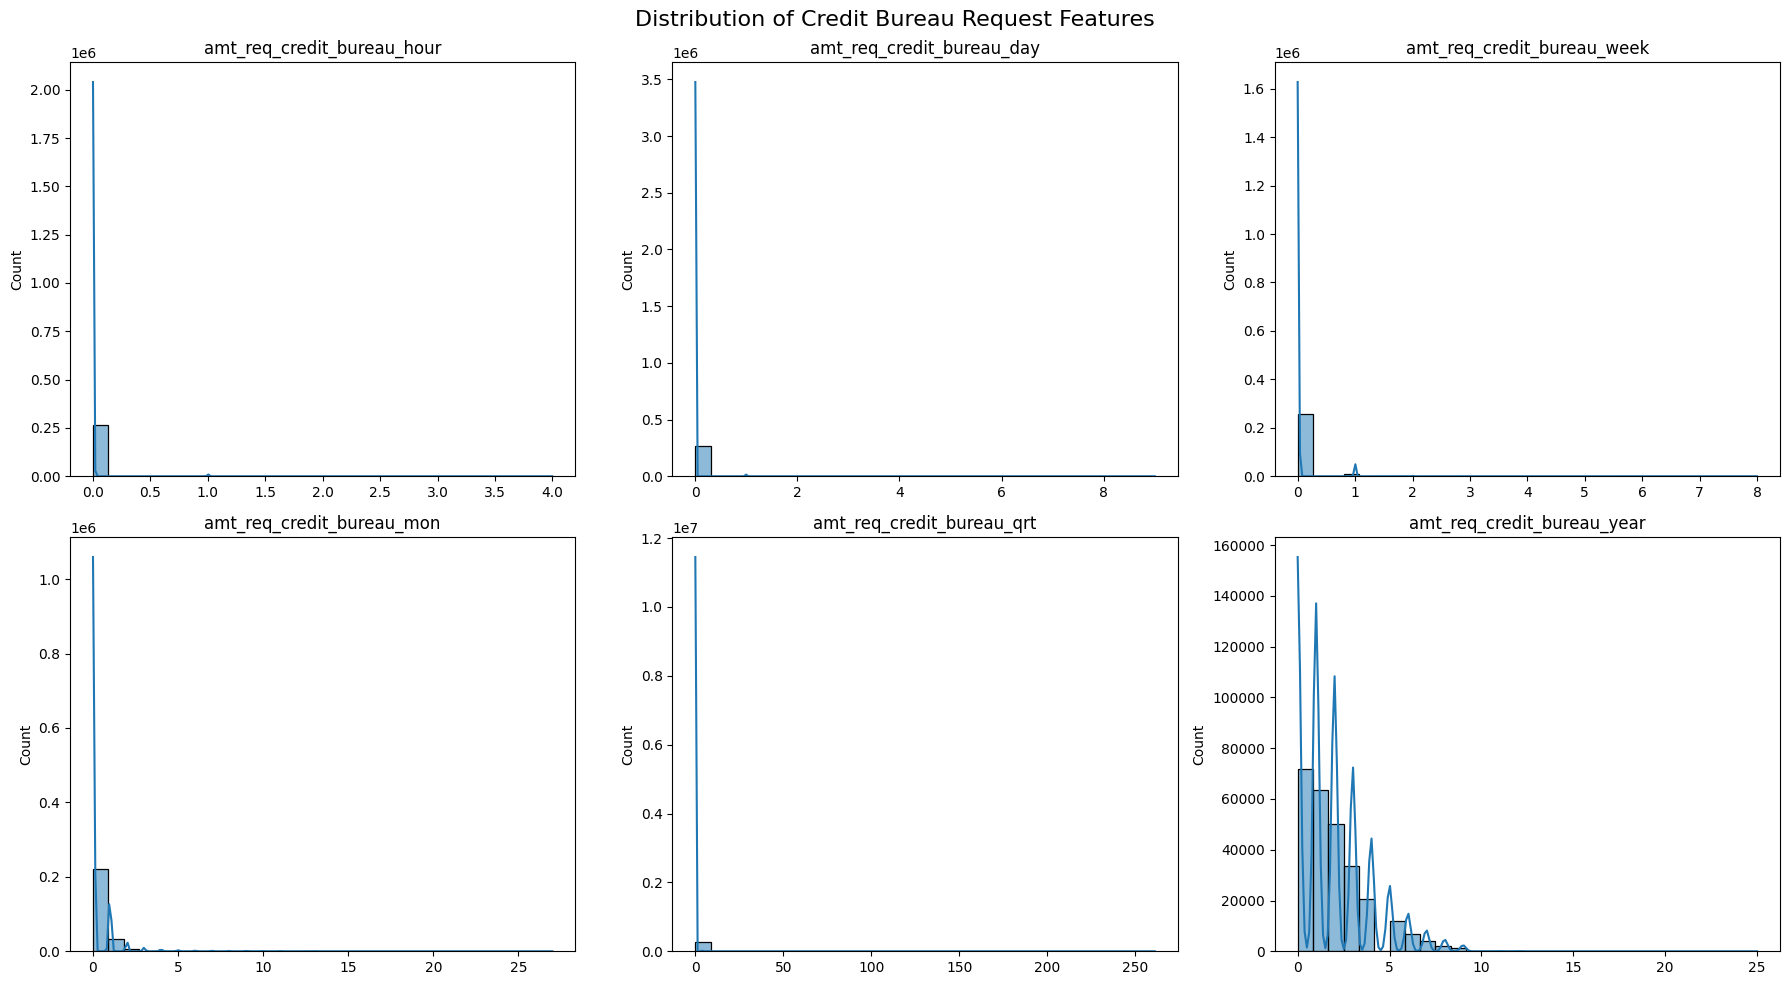

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), bureau_req_cols):
    sns.histplot(
        application_df[col],
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.suptitle(
    'Distribution of Credit Bureau Request Features',
    fontsize=16
)

plt.tight_layout()
plt.show()

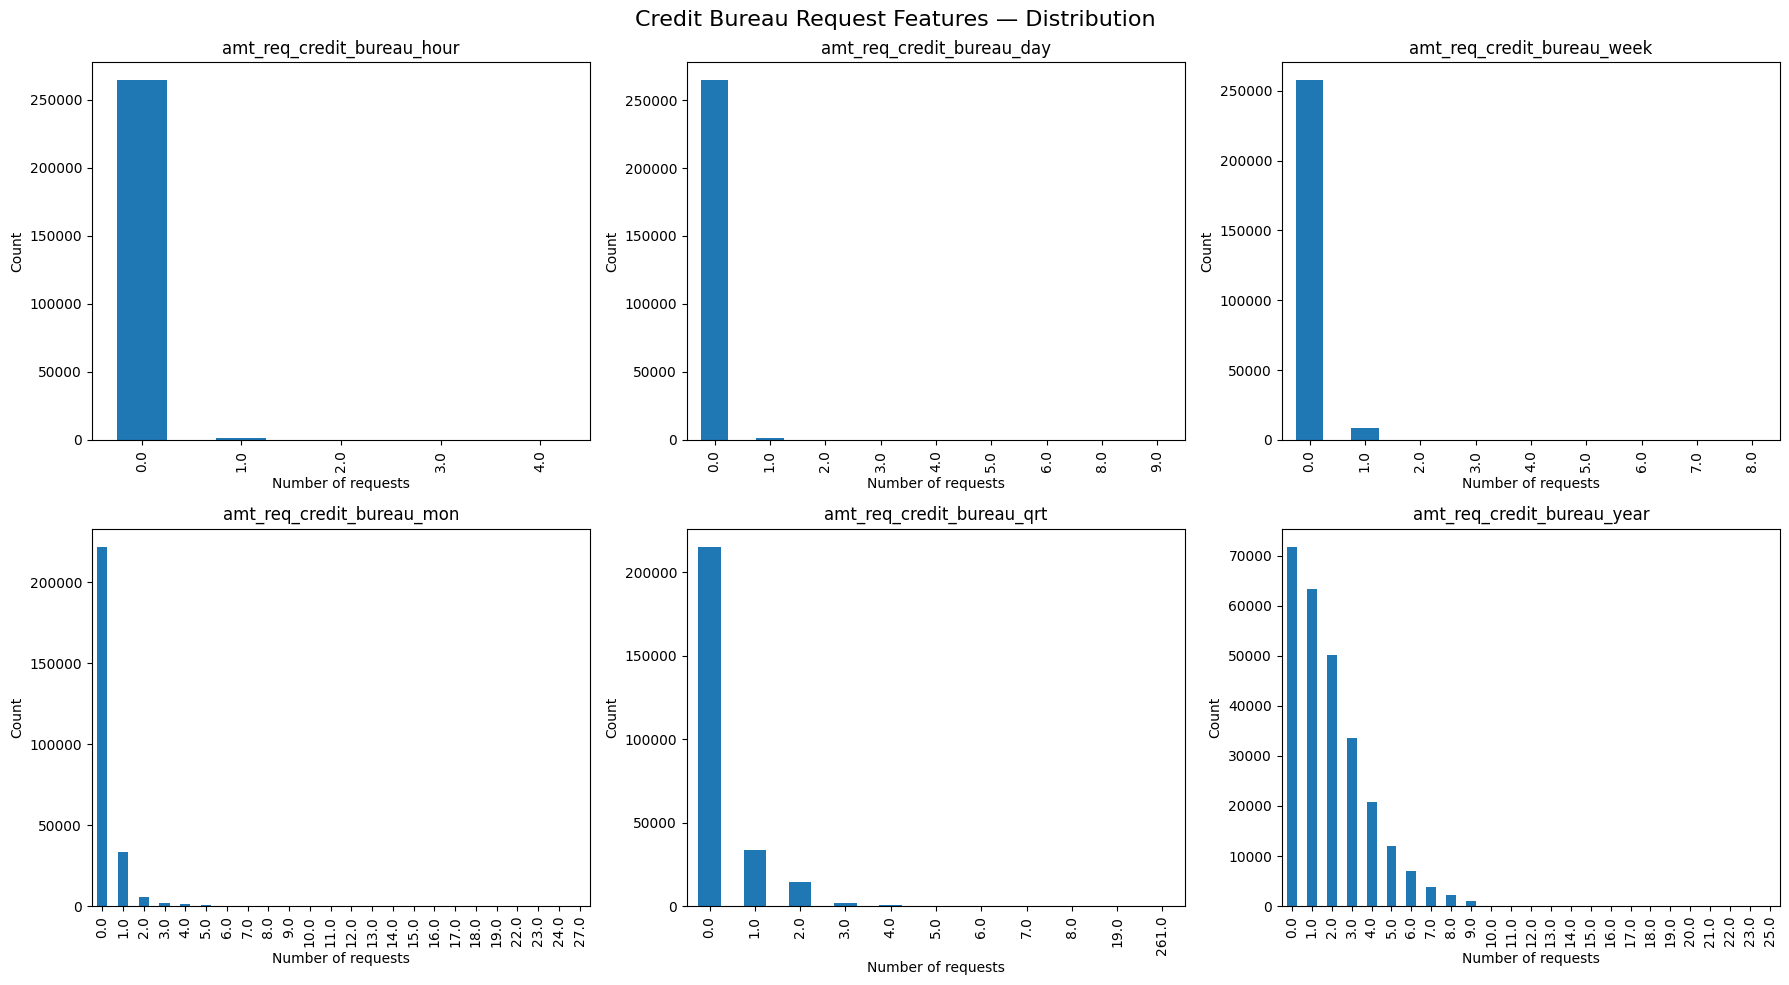

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), bureau_req_cols):
    application_df[col].value_counts().sort_index().plot(
        kind='bar',
        ax=ax
    )
    
    ax.set_title(col)
    ax.set_xlabel('Number of requests')
    ax.set_ylabel('Count')
    ax.ticklabel_format(style='plain', axis='y')

plt.suptitle(
    'Credit Bureau Request Features — Distribution',
    fontsize=16
)

plt.tight_layout()
plt.show()

## Credit Bureau Request Features — EDA Findings

The `AMT_REQ_CREDIT_BUREAU_*` features represent the number of credit-bureau inquiries made by an applicant over different time periods:

- `AMT_REQ_CREDIT_BUREAU_HOUR`
- `AMT_REQ_CREDIT_BUREAU_DAY`
- `AMT_REQ_CREDIT_BUREAU_WEEK`
- `AMT_REQ_CREDIT_BUREAU_MON`
- `AMT_REQ_CREDIT_BUREAU_QRT`
- `AMT_REQ_CREDIT_BUREAU_YEAR`

### Distribution Findings

1. **Strong zero inflation** is observed in the short-term credit-bureau request variables. Most applicants have zero recorded inquiries.

2. The percentage of zero values is particularly high for:
   - `HOUR` → approximately **86%**
   - `DAY` → approximately **86%**
   - `WEEK` → approximately **84%**
   - `MON` → approximately **72%**
   - `QRT` → approximately **70%**

3. The variables are **strongly right-skewed**, with most observations concentrated at zero or at a small number of requests and relatively few applicants having a large number of inquiries.

4. The skewness is particularly high for:
   - `HOUR` → **14.53**
   - `DAY` → **27.04**
   - `WEEK` → **9.29**
   - `MON` → **7.80**
   - `QRT` → **134.37**

5. `AMT_REQ_CREDIT_BUREAU_YEAR` shows a different pattern. It has considerably more variation across request counts and is less dominated by zero compared with the shorter time-period variables.

6. The shorter-period variables have relatively few unique values, indicating that they behave as **discrete count variables** rather than continuous numerical variables.

### Overall EDA Interpretation

The credit-bureau request variables form a related feature family and should therefore be analyzed together rather than independently.

The distributions show that most applicants have little or no recent credit-bureau inquiry activity, while a smaller group has substantially more inquiries. This results in **zero-inflated and right-skewed distributions**.

Because these are discrete count variables, frequency/bar plots are appropriate for understanding their distributions.

### Modeling Consideration

High skewness and zero inflation do **not automatically mean that these features should be removed or transformed**.

Their usefulness should be determined by examining their relationship with the target variable (`TARGET`) and their eventual contribution to the baseline model.

Therefore, the next step is to analyze whether different levels of credit-bureau inquiry activity are associated with different **default rates**.

In [61]:
default_rate_qtr=application_df.groupby('amt_req_credit_bureau_qrt')['target'].agg(['count','mean']).reset_index()
default_rate_qtr

,amt_req_credit_bureau_qrt,count,mean
0,0.0,215417,0.078476
1,1.0,33862,0.065767
2,2.0,14412,0.083472
3,3.0,1717,0.073384
4,4.0,476,0.119748
5,5.0,64,0.093750
6,6.0,28,0.250000
7,7.0,7,0.142857
8,8.0,7,0.000000
9,19.0,1,1.000000


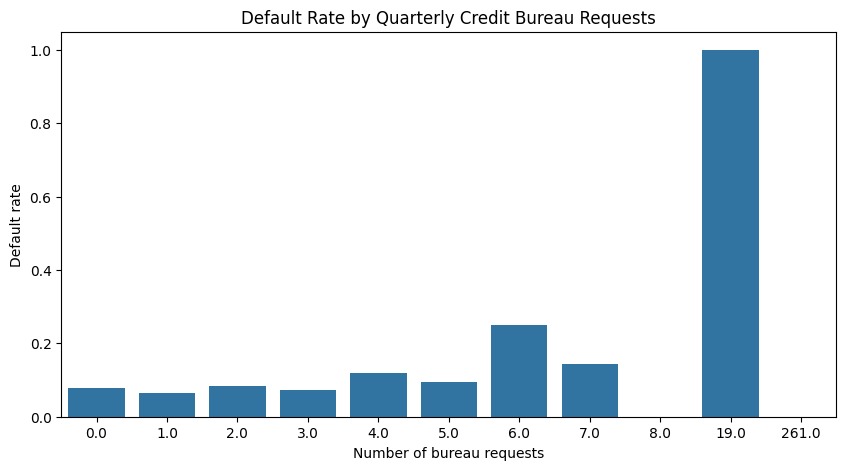

In [62]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=default_rate_qtr,
    x='amt_req_credit_bureau_qrt',
    y='mean'
)

plt.title(
    'Default Rate by Quarterly Credit Bureau Requests'
)

plt.xlabel('Number of bureau requests')
plt.ylabel('Default rate')

plt.show()

## Credit Bureau Requests — Relationship with Target

The relationship between `AMT_REQ_CREDIT_BUREAU_QRT` and `TARGET` was examined using the default rate for each number of quarterly credit-bureau requests.

For the well-populated categories (0–4 requests), the default rates range approximately from **6.6% to 12.0%**. There is no clear monotonic relationship between the number of quarterly bureau requests and default rate across these categories.

The categories with higher request counts show large fluctuations in default rate. However, these categories contain very few observations. For example, the value `19` has only **1 applicant** and a default rate of **100%**, while the value `261` also has only **1 applicant** and a default rate of **0%**. These extreme rates are therefore statistically unstable and should not be interpreted as meaningful evidence of increased or decreased credit risk.

Similarly, categories with only a small number of applicants should be interpreted cautiously because their observed default rates can vary substantially due to sample size.

### EDA Conclusion

`AMT_REQ_CREDIT_BUREAU_QRT` is strongly zero-inflated and right-skewed, but the target relationship does not show a strong or consistent pattern in the well-represented categories.

The analysis also demonstrates the importance of considering **sample size together with default rate** when analyzing categorical or discrete numerical variables.

For modeling, the feature should not be removed solely because of its skewness or zero inflation. Its usefulness will ultimately be evaluated using model performance and other feature-selection techniques.

In [63]:
default_rate_qtr.sort_values(by='count',ascending=False)

,amt_req_credit_bureau_qrt,count,mean
0,0.0,215417,0.078476
1,1.0,33862,0.065767
2,2.0,14412,0.083472
3,3.0,1717,0.073384
4,4.0,476,0.119748
5,5.0,64,0.093750
6,6.0,28,0.250000
7,7.0,7,0.142857
8,8.0,7,0.000000
9,19.0,1,1.000000


In [64]:
application_df[
    application_df['amt_req_credit_bureau_qrt'] > 8
][[
    'sk_id_curr',
    'amt_req_credit_bureau_qrt',
    'target'
]]

,sk_id_curr,amt_req_credit_bureau_qrt,target
239474,377322,261.0,0
253541,393383,19.0,1


In [65]:
application_df['amt_req_credit_bureau_qrt'].describe()

count    265992.000000
mean          0.265474
std           0.794056
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         261.000000
Name: amt_req_credit_bureau_qrt, dtype: float64

In [66]:
application_df['amt_req_credit_bureau_qrt'].isna().sum()

np.int64(41519)

In [67]:
bureau_req_cols

['amt_req_credit_bureau_hour',
 'amt_req_credit_bureau_day',
 'amt_req_credit_bureau_week',
 'amt_req_credit_bureau_mon',
 'amt_req_credit_bureau_qrt',
 'amt_req_credit_bureau_year']

In [68]:
application_df[bureau_req_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
amt_req_credit_bureau_hour,265992.0,0.006402,0.083849,0.0,0.0,0.0,0.0,4.0
amt_req_credit_bureau_day,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
amt_req_credit_bureau_week,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
amt_req_credit_bureau_mon,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
amt_req_credit_bureau_qrt,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0
amt_req_credit_bureau_year,265992.0,1.899974,1.869295,0.0,0.0,1.0,3.0,25.0


In [69]:
(application_df[bureau_req_cols].isnull().mean()*100).sort_values(ascending=False)

amt_req_credit_bureau_hour    13.501631
amt_req_credit_bureau_day     13.501631
amt_req_credit_bureau_week    13.501631
amt_req_credit_bureau_mon     13.501631
amt_req_credit_bureau_qrt     13.501631
amt_req_credit_bureau_year    13.501631
dtype: float64

In [70]:
application_df[bureau_req_cols].corr()

,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
amt_req_credit_bureau_hour,1.000000,0.230374,0.004706,-0.000018,-0.002716,-0.004597
amt_req_credit_bureau_day,0.230374,1.000000,0.217412,-0.005258,-0.004416,-0.003355
amt_req_credit_bureau_week,0.004706,0.217412,1.000000,-0.014096,-0.015115,0.018917
amt_req_credit_bureau_mon,-0.000018,-0.005258,-0.014096,1.000000,-0.007789,-0.004975
amt_req_credit_bureau_qrt,-0.002716,-0.004416,-0.015115,-0.007789,1.000000,0.076208
amt_req_credit_bureau_year,-0.004597,-0.003355,0.018917,-0.004975,0.076208,1.000000


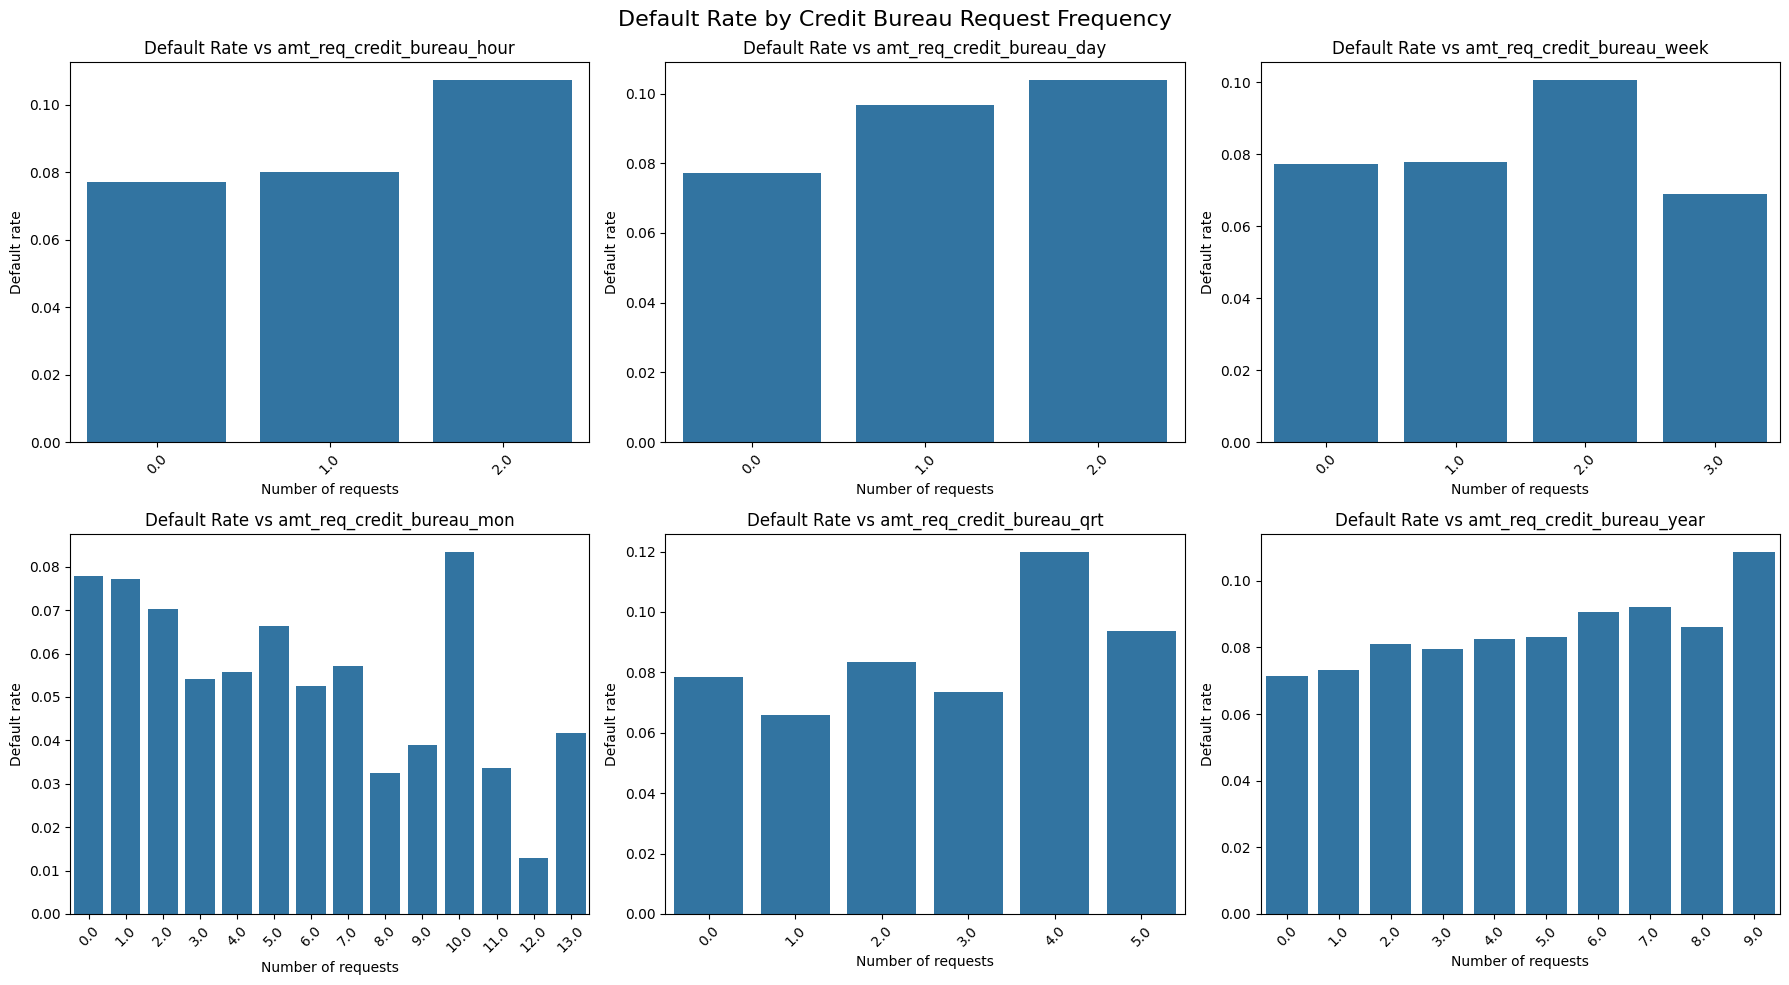

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), bureau_req_cols):

    default_rate = (
        application_df
        .groupby(col)['target']
        .agg(['count', 'mean'])
        .reset_index()
    )

    # Keep only groups with at least 50 observations
    default_rate = default_rate[default_rate['count'] >= 50]

    sns.barplot(
        data=default_rate,
        x=col,
        y='mean',
        ax=ax
    )

    ax.set_title(f'Default Rate vs {col}')
    ax.set_xlabel('Number of requests')
    ax.set_ylabel('Default rate')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    'Default Rate by Credit Bureau Request Frequency',
    fontsize=16
)

plt.tight_layout()
plt.show()

## Credit Bureau Request Features — EDA Findings

### Features Analyzed

- `amt_req_credit_bureau_hour`
- `amt_req_credit_bureau_day`
- `amt_req_credit_bureau_week`
- `amt_req_credit_bureau_mon`
- `amt_req_credit_bureau_qrt`
- `amt_req_credit_bureau_year`

### Distribution & Missing Values

- All six features contain approximately **13.5% missing values**.
- `hour`, `day`, `week`, `month`, and `quarter` are highly **zero-inflated**, with the median and 75th percentile equal to 0.
- `year` has a higher frequency of requests, with a median of 1 and 75th percentile of 3.
- The features are generally **right-skewed**, with a small number of customers having unusually high bureau-request counts.
- `amt_req_credit_bureau_qrt` contains an extreme value of **261**, while `amt_req_credit_bureau_year` has a maximum of 25.
- Extreme values were retained during EDA and will be considered during preprocessing.

### Relationship with Target

- `hour` and `day` show relatively weak relationships with the target.
- `week` shows some variation in default rate but no clear monotonic pattern.
- `month` shows noticeable but non-linear variation in default rates across request counts.
- `quarter` shows increased default rates at some higher request levels.
  - Customers with **0 quarterly requests** had a default rate of approximately **7.85%**.
  - Customers with **4 quarterly requests** had a default rate of approximately **11.97%**.
- `year` shows the clearest overall upward tendency in default rate as annual bureau requests increase.
- Extremely sparse request-count groups were excluded from the target-rate visualization because their default rates are statistically unstable.

### Correlation

- Correlation among the six bureau-request features is generally low.
- The strongest relationships are:
  - `hour` and `day`: **0.23**
  - `day` and `week`: **0.22**
  - `quarter` and `year`: **0.08**
- There is no strong linear correlation between most features in this group.
- Low correlation between features does **not** mean that a feature has no predictive relationship with the target.

### Overall EDA Conclusion

The credit-bureau request features are highly sparse and right-skewed, with consistent missingness across the feature group. Their relationship with default risk is generally weak for shorter time windows but becomes more noticeable for monthly, quarterly, and especially annual request activity.

`amt_req_credit_bureau_year` appears to show the strongest potential target relationship, while the remaining features may still provide useful information when combined with other predictors.

### Modeling Note

No features were removed based solely on this EDA.

Missing values, extreme values, and feature usefulness will be addressed during the **data-cleaning and baseline-modeling stages**.

In [72]:
application_df.columns


Index(['sk_id_curr', 'target', 'name_contract_type', 'code_gender',
       'flag_own_car', 'flag_own_realty', 'cnt_children', 'amt_income_total',
       'amt_credit', 'amt_annuity',
       ...
       'flag_document_19', 'flag_document_20', 'flag_document_21',
       'amt_req_credit_bureau_hour', 'amt_req_credit_bureau_day',
       'amt_req_credit_bureau_week', 'amt_req_credit_bureau_mon',
       'amt_req_credit_bureau_qrt', 'amt_req_credit_bureau_year',
       'income_bands'],
      dtype='object', length=123)

In [73]:
days_related_features=[col for col in application_df.columns if col.startswith('days')]
days_related_features

['days_birth',
 'days_employed',
 'days_registration',
 'days_id_publish',
 'days_last_phone_change']

In [74]:
application_df[days_related_features].describe().T

,count,mean,std,min,25%,50%,75%,max
days_birth,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
days_employed,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
days_registration,307511.0,-4986.120328,3522.886321,-24672.0,-7479.5,-4504.0,-2010.0,0.0
days_id_publish,307511.0,-2994.202373,1509.450419,-7197.0,-4299.0,-3254.0,-1720.0,0.0
days_last_phone_change,307510.0,-962.858788,826.808487,-4292.0,-1570.0,-757.0,-274.0,0.0


In [75]:
application_df[days_related_features].isna().sum()

days_birth                0
days_employed             0
days_registration         0
days_id_publish           0
days_last_phone_change    1
dtype: int64

In [76]:
(application_df[days_related_features]==365243).sum()

days_birth                    0
days_employed             55374
days_registration             0
days_id_publish               0
days_last_phone_change        0
dtype: int64

In [77]:
(application_df.loc[:,days_related_features]==365243).sum()

days_birth                    0
days_employed             55374
days_registration             0
days_id_publish               0
days_last_phone_change        0
dtype: int64

In [78]:
application_df.groupby('target')['days_birth'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,282686.0,-16138.176397,4364.200856,-25229.0,-19793.75,-15877.0,-12536.0,-7489.0
1,24825.0,-14884.828077,4192.844583,-25168.0,-18037.00,-14282.0,-11396.0,-7678.0


In [79]:
application_df['age_years_eda']=(abs(application_df['days_birth'])/365).round(2)
application_df['age_years_eda'].head()

0    25.92
1    45.93
2    52.18
3    52.07
4    54.61
Name: age_years_eda, dtype: float64

In [80]:
application_df.groupby('target')['age_years_eda'].mean()


target
0    44.214185
1    40.780352
Name: age_years_eda, dtype: float64

In [81]:
application_df['age_group_eda'] = pd.cut(
    application_df['age_years_eda'],
    bins=[20, 25, 30, 35, 40, 45, 50, 60, 100],
    labels=['20-25','25-30','30-35','35-40','40-45','45-50','50-60','60-100'],
    include_lowest=True
)
application_df['age_group_eda'].head()

0    25-30
1    45-50
2    50-60
3    50-60
4    50-60
Name: age_group_eda, dtype: category
Categories (8, object): ['20-25' < '25-30' < '30-35' < '35-40' < '40-45' < '45-50' < '50-60' < '60-100']

In [82]:
age_default_rate=application_df.groupby('age_group_eda')['target'].mean()*100
age_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17312\998862545.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default_rate=application_df.groupby('age_group_eda')['target'].mean()*100


age_group_eda
20-25     12.295688
25-30     11.142214
30-35     10.280066
35-40      8.947528
40-45      7.846169
45-50      7.415315
50-60      6.127876
60-100     4.923795
Name: target, dtype: float64

In [83]:
application_df.groupby('target')['days_employed'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,282686.0,65696.146123,142877.810161,-17912.0,-2813.0,-1235.0,-278.0,365243.0
1,24825.0,42394.675448,119484.634253,-16069.0,-2156.0,-1034.0,-379.0,365243.0


In [84]:
application_df.groupby('days_employed')['target'].agg(['count','mean']).sort_values(by='count',ascending=False)

,count,mean
days_employed,,
365243,55374,0.053996
-200,156,0.134615
-224,152,0.085526
-199,151,0.125828
-230,151,0.099338
...,...,...
-11027,1,0.000000
-11030,1,0.000000
-11031,1,0.000000


In [85]:
application_df.loc[
    application_df['days_employed'] != 365243,
    'days_employed'
].describe()

count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: days_employed, dtype: float64

In [86]:
application_df['days_years_employed']=np.where(application_df['days_employed']==365243,np.nan,
                                               (abs(application_df['days_employed'])/365).round(2))
application_df['days_years_employed'].head()

0    1.75
1    3.25
2    0.62
3    8.33
4    8.32
Name: days_years_employed, dtype: float64

In [87]:
application_df['days_years_employed'].isna().sum()

np.int64(55374)

In [88]:
application_df['days_group_employed']=pd.cut(application_df['days_years_employed'],
                                            bins=[0,2,5,10,20,30,40,50],
                                            labels=['0-2','2-5','5-10', '10-20','20-30','30-40','40-50'],
                                            include_lowest=True)
application_df['days_group_employed'].head()

0     0-2
1     2-5
2     0-2
3    5-10
4    5-10
Name: days_group_employed, dtype: category
Categories (7, object): ['0-2' < '2-5' < '5-10' < '10-20' < '20-30' < '30-40' < '40-50']

In [89]:
employment_default_rate=application_df.groupby('days_group_employed')['target'].mean()*100
employment_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17312\3063206019.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  employment_default_rate=application_df.groupby('days_group_employed')['target'].mean()*100


days_group_employed
0-2      11.206263
2-5      10.071679
5-10      7.372625
10-20     5.512714
20-30     4.483553
30-40     3.466956
40-50     0.427350
Name: target, dtype: float64

In [90]:
employment_default_summary = (
    application_df.groupby('days_group_employed', observed=True)['target']
    .agg(['count', 'mean'])
)

employment_default_summary['default_rate'] = (
    employment_default_summary['mean'] * 100
)

employment_default_summary

,count,mean,default_rate
days_group_employed,,,
0-2,59904,0.112063,11.206263
2-5,76452,0.100717,10.071679
5-10,64848,0.073726,7.372625
10-20,38384,0.055127,5.512714
20-30,9546,0.044836,4.483553
30-40,2769,0.034670,3.466956
40-50,234,0.004274,0.427350


In [91]:
remaining_days_features = [
    'days_registration',
    'days_id_publish',
    'days_last_phone_change'
]

for col in remaining_days_features:
    print(f"\n{'='*50}")
    print(f"{col}")
    print('='*50)
    print(application_df[col].describe())


days_registration
count    307511.000000
mean      -4986.120328
std        3522.886321
min      -24672.000000
25%       -7479.500000
50%       -4504.000000
75%       -2010.000000
max           0.000000
Name: days_registration, dtype: float64

days_id_publish
count    307511.000000
mean      -2994.202373
std        1509.450419
min       -7197.000000
25%       -4299.000000
50%       -3254.000000
75%       -1720.000000
max           0.000000
Name: days_id_publish, dtype: float64

days_last_phone_change
count    307510.000000
mean       -962.858788
std         826.808487
min       -4292.000000
25%       -1570.000000
50%        -757.000000
75%        -274.000000
max           0.000000
Name: days_last_phone_change, dtype: float64


In [92]:
for col in remaining_days_features:
    print(f"{col}: {application_df[col].isna().sum()} missing values")

days_registration: 0 missing values
days_id_publish: 0 missing values
days_last_phone_change: 1 missing values


In [93]:
application_df.groupby('days_registration')['target'].agg(
    ['count', 'mean']
).sort_values('count', ascending=False).head(10)

,count,mean
days_registration,,
-1.0,113,0.150442
-7.0,98,0.122449
-6.0,96,0.135417
-2.0,92,0.173913
-4.0,92,0.108696
-5.0,86,0.127907
-9.0,84,0.119048
-3.0,84,0.107143
0.0,80,0.112500


In [94]:
application_df['days_registration_years']=abs(application_df['days_registration'])/365
application_df['days_registration_years'].head()

0     9.994521
1     3.249315
2    11.671233
3    26.939726
4    11.810959
Name: days_registration_years, dtype: float64

In [95]:
application_df['days_registration_group']=pd.cut(application_df['days_registration_years'], 
                                                 bins=[0,2,5,10,20,30,40,50,70], 
                                                 labels=['0-2','2-5','5-10','10-20','20-30','30-40','40-50','50-70'], 
                                                 include_lowest=True) 
application_df['days_registration_group'].head()

0     5-10
1      2-5
2    10-20
3    20-30
4    10-20
Name: days_registration_group, dtype: category
Categories (8, object): ['0-2' < '2-5' < '5-10' < '10-20' < '20-30' < '30-40' < '40-50' < '50-70']

In [96]:
registration_default_rate=application_df.groupby('days_registration_group')['target'].mean()*100 
registration_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17312\767750666.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  registration_default_rate=application_df.groupby('days_registration_group')['target'].mean()*100


days_registration_group
0-2      9.645530
2-5      8.793764
5-10     8.719376
10-20    8.316362
20-30    6.611356
30-40    5.659179
40-50    3.815869
50-70    5.000000
Name: target, dtype: float64

In [97]:
application_df['days_published_years']=abs(application_df['days_id_publish'])/365
application_df['days_published_years'].head()

0    5.808219
1    0.797260
2    6.934247
3    6.676712
4    9.473973
Name: days_published_years, dtype: float64

In [98]:
application_df['days_published_years'].describe()

count    307511.000000
mean          8.203294
std           4.135481
min           0.000000
25%           4.712329
50%           8.915068
75%          11.778082
max          19.717808
Name: days_published_years, dtype: float64

In [99]:
application_df['days_published_group']=pd.cut(application_df['days_published_years'], 
                                                 bins=[0,2,5,10,20], 
                                                 labels=['0-2','2-5','5-10','10-20'],
                                                 include_lowest=True) 
application_df['days_published_group'].head()

0    5-10
1     0-2
2    5-10
3    5-10
4    5-10
Name: days_published_group, dtype: category
Categories (4, object): ['0-2' < '2-5' < '5-10' < '10-20']

In [100]:
published_default_rate=application_df.groupby('days_published_group')['target'].mean()*100
published_default_rate

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17312\856215310.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  published_default_rate=application_df.groupby('days_published_group')['target'].mean()*100


days_published_group
0-2      10.180283
2-5       9.684120
5-10      8.455414
10-20     6.700202
Name: target, dtype: float64

In [101]:
application_df.groupby('days_published_group')['target'].agg(['count','mean'])

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17312\2389368336.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  application_df.groupby('days_published_group')['target'].agg(['count','mean'])


,count,mean
days_published_group,,
0-2,30785,0.101803
2-5,51032,0.096841
5-10,92698,0.084554
10-20,132996,0.067002


In [102]:
application_df['days_phone_change_years'] = (
    abs(application_df['days_last_phone_change']) / 365
)

In [103]:
application_df['days_phone_change_years'].describe()

count    307510.000000
mean          2.637969
std           2.265229
min           0.000000
25%           0.750685
50%           2.073973
75%           4.301370
max          11.758904
Name: days_phone_change_years, dtype: float64

In [104]:
application_df['phone_change_group_eda'] = pd.cut(
    application_df['days_phone_change_years'],
    bins=[0, 1, 2, 3, 5, 8, 12],
    labels=['0-1', '1-2', '2-3', '3-5', '5-8', '8-12'],
    include_lowest=True
)

In [105]:
phone_change_group = application_df.groupby('phone_change_group_eda')['target'].mean()*100
    
phone_change_group

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17312\1623727043.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phone_change_group = application_df.groupby('phone_change_group_eda')['target'].mean()*100


phone_change_group_eda
0-1     9.576765
1-2     9.296958
2-3     8.269089
3-5     6.710393
5-8     5.789531
8-12    4.546234
Name: target, dtype: float64

In [106]:
phone_change_summary = (
    application_df.groupby(
        'phone_change_group_eda',
        observed=True
    )['target']
    .agg(['count', 'mean'])
)

phone_change_summary['default_rate'] = (
    phone_change_summary['mean'] * 100
)

phone_change_summary

,count,mean,default_rate
phone_change_group_eda,,,
0-1,92620,0.095768,9.576765
1-2,57621,0.092970,9.296958
2-3,37876,0.082691,8.269089
3-5,67999,0.067104,6.710393
5-8,45565,0.057895,5.789531
8-12,5829,0.045462,4.546234


In [107]:
days_related_features

['days_birth',
 'days_employed',
 'days_registration',
 'days_id_publish',
 'days_last_phone_change']

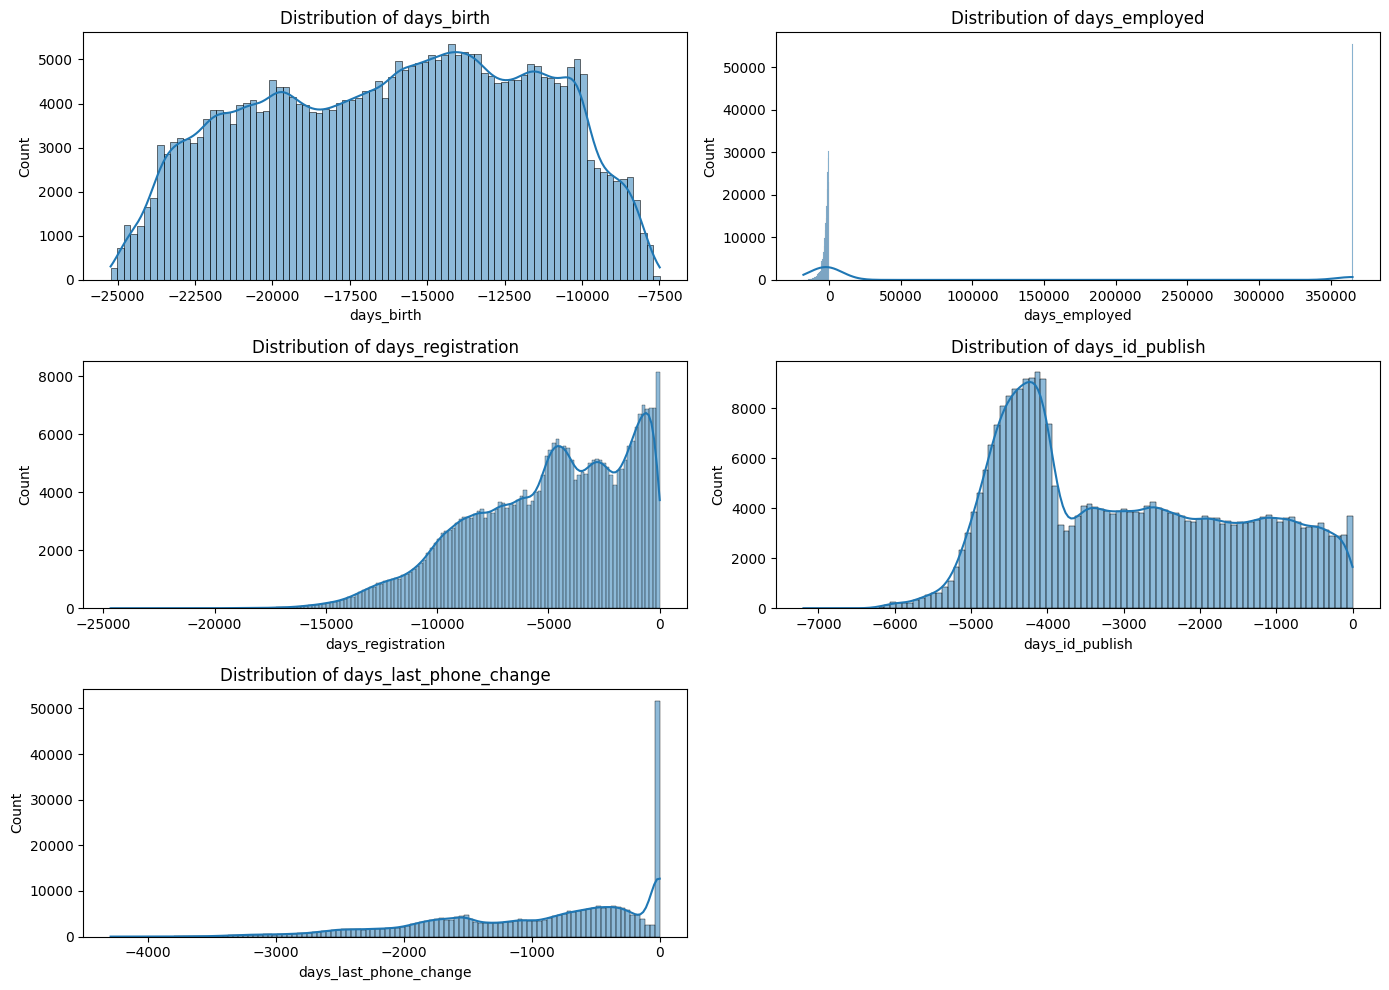

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, days_related_features):
    sns.histplot(data=application_df, x=feature, kde=True, ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

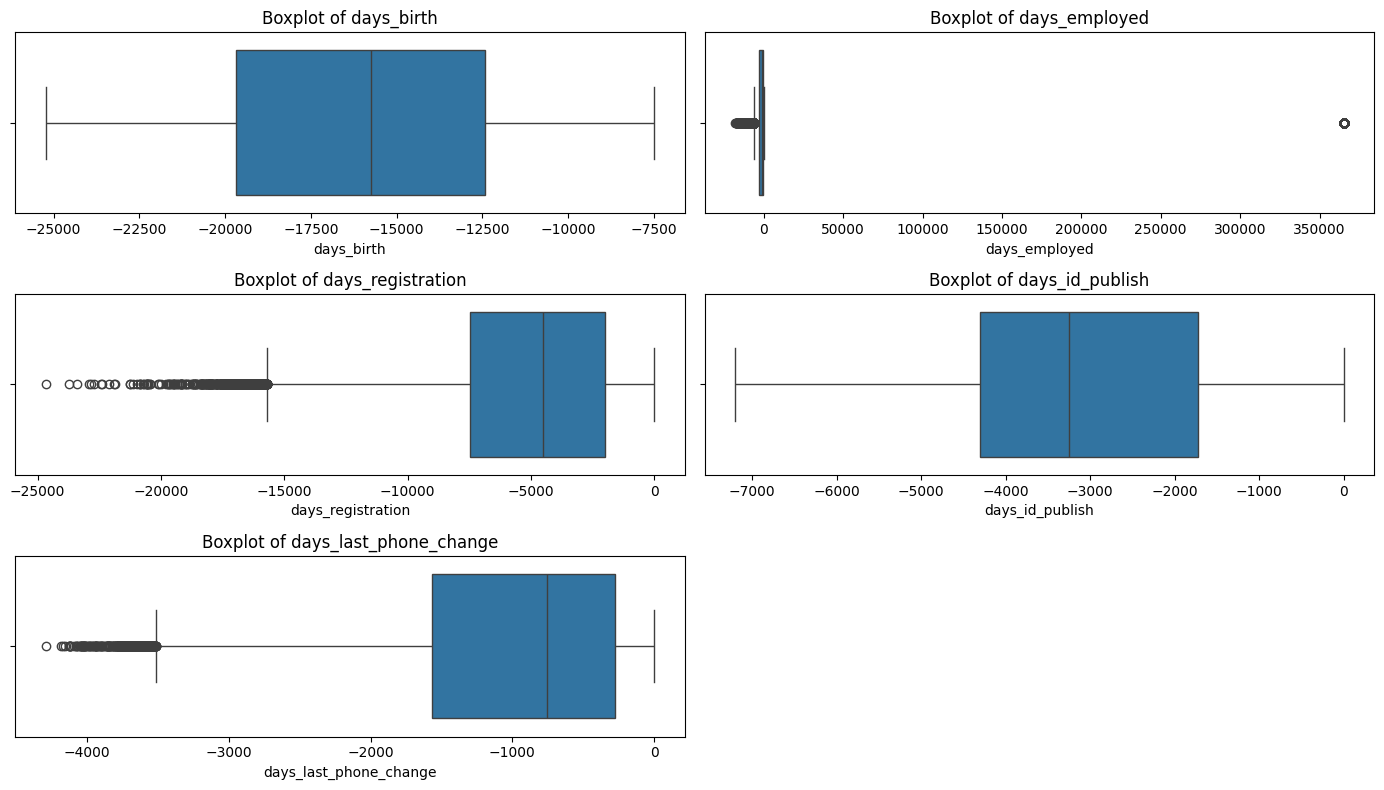

In [109]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))

for ax, feature in zip(axes.flat, days_related_features):
    sns.boxplot(x=application_df[feature], ax=ax)
    ax.set_title(f'Boxplot of {feature}')
    ax.set_xlabel(feature)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [110]:
days_employed_valid = application_df.loc[
    application_df['days_employed'] != 365243,
    'days_employed'
]

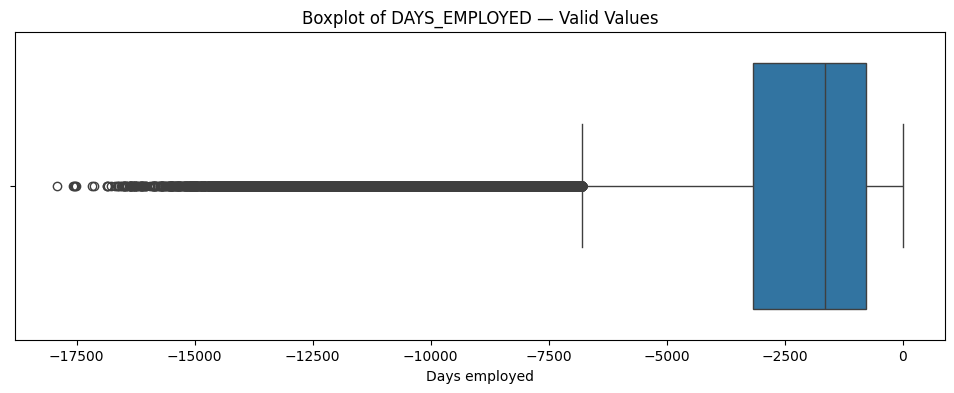

In [111]:
plt.figure(figsize=(12, 4))

sns.boxplot(x=days_employed_valid)

plt.title('Boxplot of DAYS_EMPLOYED — Valid Values')
plt.xlabel('Days employed')

plt.show()

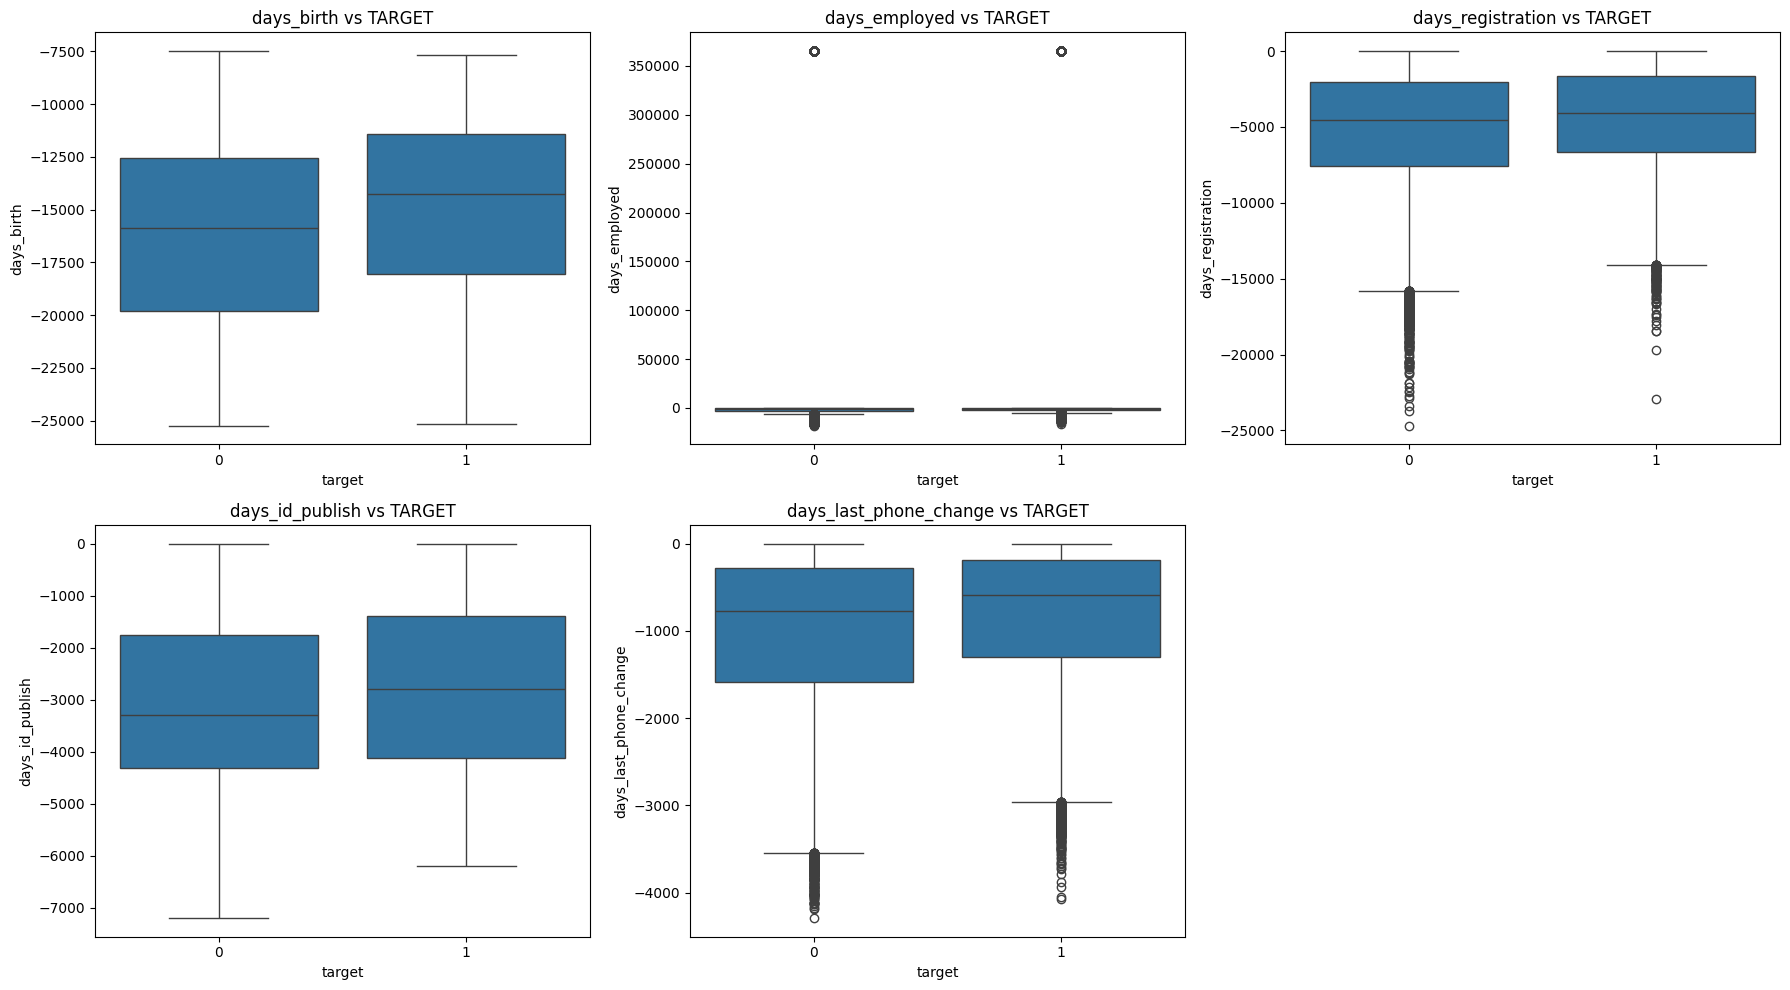

In [112]:


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flat, days_related_features):
    sns.boxplot(
        data=application_df,
        x='target',
        y=feature,
        ax=ax
    )
    
    ax.set_title(f'{feature} vs TARGET')
    ax.set_xlabel('target')
    ax.set_ylabel(feature)

# Hide unused subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [113]:
days_related_group=[age_default_rate,employment_default_rate,registration_default_rate,
                    published_default_rate,phone_change_group]
names = [
    'Age Group',
    'Employment Duration',
    'Registration Duration',
    'ID Publication Duration',
    'Phone Change Duration'
]

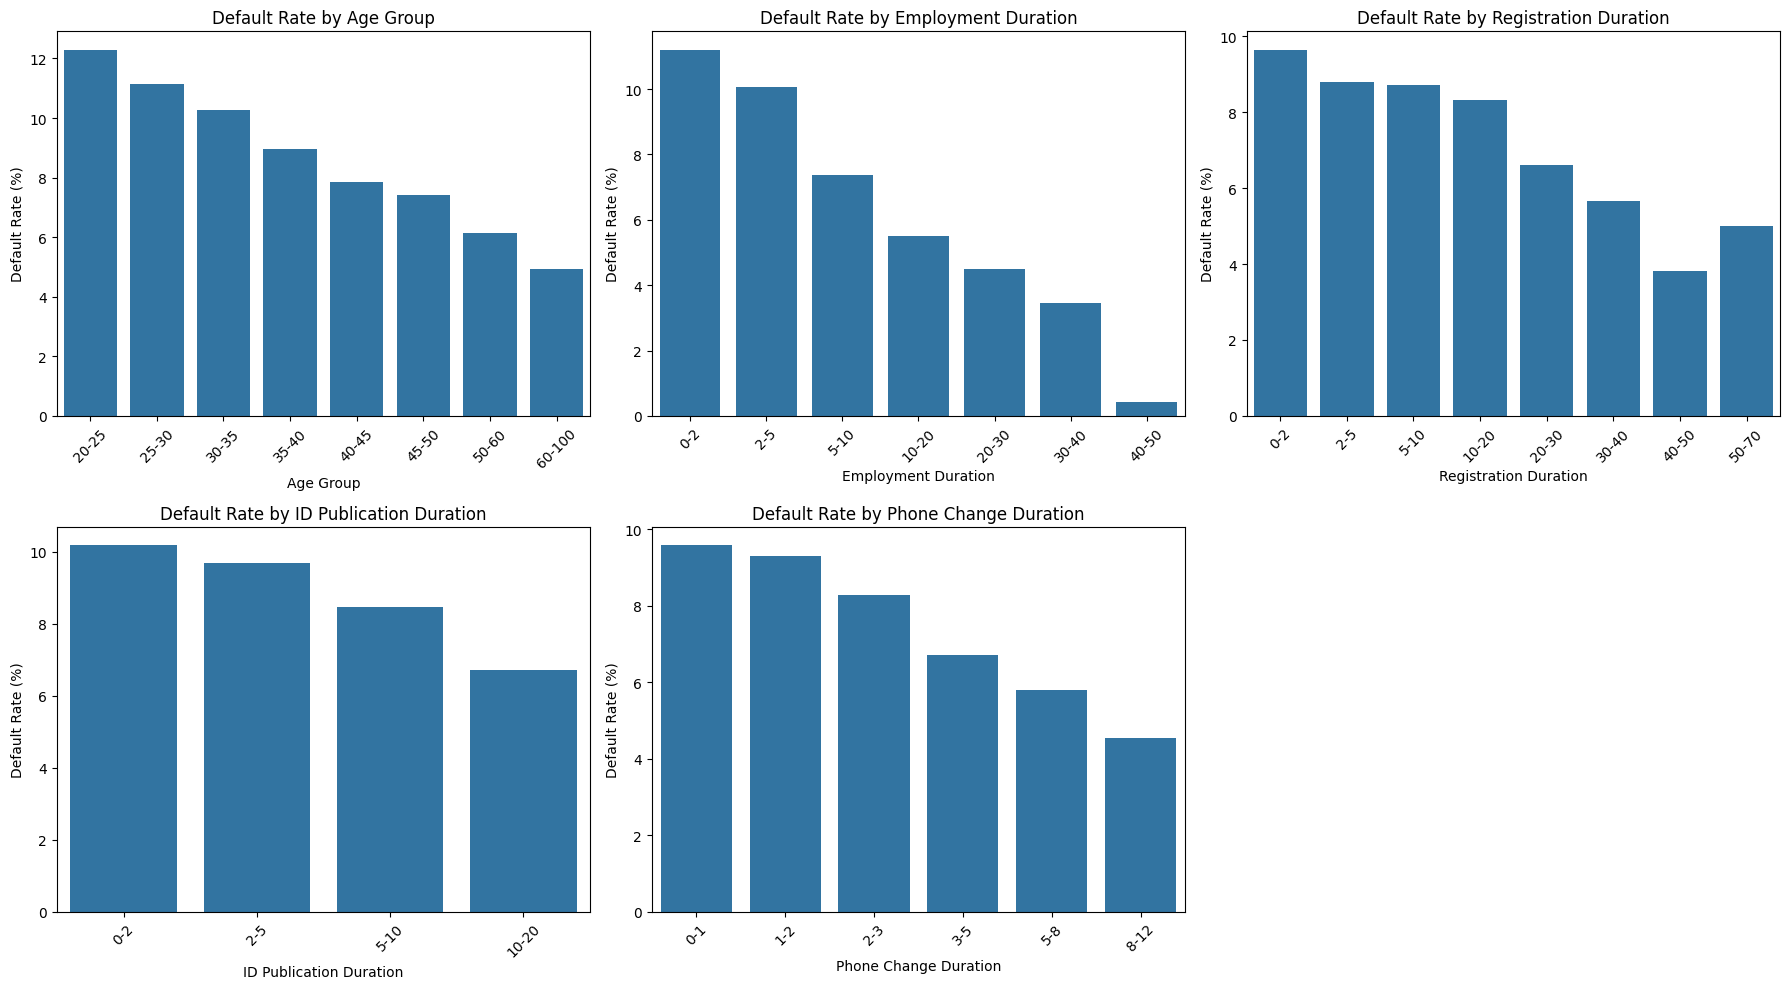

In [114]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, group, name in zip(axes.flat, days_related_group, names):

    sns.barplot(
        x=group.index,
        y=group.values,
        ax=ax
    )

    ax.set_title(f'Default Rate by {name}')
    ax.set_xlabel(name)
    ax.set_ylabel('Default Rate (%)')
    ax.tick_params(axis='x', rotation=45)

# Hide the unused 6th subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

## Day-Related Features — EDA Findings

The day-related features were analyzed using distribution plots, boxplots, feature-vs-target boxplots, and grouped default-rate analysis.

### 1. Age (`days_birth`)

- The distribution of `days_birth` is broad, with no major data-quality anomaly observed.
- The boxplot shows a noticeable difference between defaulters and non-defaulters.
- Default rate decreases consistently as applicant age increases.
- Default rate decreases from approximately **12.30% for applicants aged 20–25** to **4.92% for applicants aged 60–100**.
- This indicates a strong negative relationship between applicant age and default risk.
- Younger applicants represent a higher observed default-risk segment in the dataset.

### 2. Employment Duration (`days_employed`)

- `days_employed` has a highly skewed distribution.
- The value **365243** is an extreme/special value and does not represent a realistic employment duration.
- This value needs to be handled separately during data cleaning/feature engineering rather than being treated as a normal employment duration.
- After excluding the special value for visualization, the feature shows a long tail toward longer employment durations.
- Default rate decreases substantially as employment duration increases:
  - **11.21%** for 0–2 years
  - **10.07%** for 2–5 years
  - **7.37%** for 5–10 years
  - **5.51%** for 10–20 years
  - **4.48%** for 20–30 years
  - **3.47%** for 30–40 years
  - **0.43%** for 40–50 years
- This indicates a strong negative relationship between employment duration and default risk.
- The 40–50 year group has an unusually low default rate and should be checked for sample size before drawing a strong conclusion.

### 3. Registration History (`days_registration`)

- `days_registration` is strongly skewed toward more recent values, with a long tail toward older registration history.
- The boxplot shows numerous observations outside the lower whisker, reflecting the skewed distribution rather than necessarily invalid data.
- Default rate generally decreases as the registration history becomes older.
- Default rate decreases from **9.65% for 0–2 years** to **3.82% for 40–50 years**.
- The final 50–70 year group increases to **5.00%**, indicating that the relationship is not perfectly monotonic at the extreme end.
- Overall, the feature shows a moderate negative relationship with default risk.

### 4. ID Publication History (`days_id_publish`)

- `days_id_publish` shows a non-normal distribution with a strong concentration around earlier values and a broader secondary pattern.
- The boxplot indicates a shift in the distribution between defaulters and non-defaulters.
- Default rate decreases consistently across the available groups:
  - **10.18%** for 0–2 years
  - **9.68%** for 2–5 years
  - **8.46%** for 5–10 years
  - **6.70%** for 10–20 years
- This indicates a clear negative relationship between the time since ID publication and default risk.

### 5. Last Phone Change (`days_last_phone_change`)

- The distribution is strongly skewed with a large concentration around zero and a long negative tail.
- The value zero is not automatically considered an error because it can represent a phone change occurring on or around the application date.
- The boxplot shows that defaulters tend to have more recent phone-change dates.
- Default rate decreases consistently as the time since the last phone change increases:
  - **9.58%** for 0–1 years
  - **9.30%** for 1–2 years
  - **8.27%** for 2–3 years
  - **6.71%** for 3–5 years
  - **5.79%** for 5–8 years
  - **4.55%** for 8–12 years
- This indicates a strong negative relationship between time since the last phone change and default risk.

### Overall Conclusion

The day-related features show meaningful relationships with credit default risk.

- **`days_birth`**: younger applicants have higher observed default rates.
- **`days_employed`**: longer employment duration is associated with lower default rates.
- **`days_registration`**: older registration history generally corresponds to lower default rates, although the relationship is slightly non-monotonic at the extreme end.
- **`days_id_publish`**: longer time since ID publication is associated with lower default rates.
- **`days_last_phone_change`**: longer time since the last phone change is associated with lower default rates.

Overall, these features appear to contain useful predictive information and should be retained for further modeling analysis.

The special value **365243 in `days_employed`** requires dedicated treatment during the data-cleaning stage. Statistical outliers identified through boxplots should not be removed automatically because they may represent legitimate applicants and can potentially contain predictive information.

In [115]:
col_list=application_df.columns.tolist()
col_list

['sk_id_curr',
 'target',
 'name_contract_type',
 'code_gender',
 'flag_own_car',
 'flag_own_realty',
 'cnt_children',
 'amt_income_total',
 'amt_credit',
 'amt_annuity',
 'amt_goods_price',
 'name_type_suite',
 'name_income_type',
 'name_education_type',
 'name_family_status',
 'name_housing_type',
 'region_population_relative',
 'days_birth',
 'days_employed',
 'days_registration',
 'days_id_publish',
 'own_car_age',
 'flag_mobil',
 'flag_emp_phone',
 'flag_work_phone',
 'flag_cont_mobile',
 'flag_phone',
 'flag_email',
 'occupation_type',
 'cnt_fam_members',
 'region_rating_client',
 'region_rating_client_w_city',
 'weekday_appr_process_start',
 'hour_appr_process_start',
 'reg_region_not_live_region',
 'reg_region_not_work_region',
 'live_region_not_work_region',
 'reg_city_not_live_city',
 'reg_city_not_work_city',
 'live_city_not_work_city',
 'organization_type',
 'ext_source_1',
 'ext_source_2',
 'ext_source_3',
 'apartments_avg',
 'basementarea_avg',
 'years_beginexpluatation_a

In [116]:
print(len(col_list))

133


In [118]:
application_df.drop(['income_bands','age_years_eda','age_group_eda','days_years_employed',
 'days_group_employed','days_registration_years','days_registration_group','days_published_years',
 'days_published_group','days_phone_change_years','phone_change_group_eda'],axis=1,inplace=True)

In [119]:
application_df.shape

(307511, 122)

In [120]:
amt_related_features=[ 'amt_income_total','amt_credit','amt_annuity','amt_goods_price']
amt_related_features

['amt_income_total', 'amt_credit', 'amt_annuity', 'amt_goods_price']